# 🧠 Notebook 03 — Deep Learning (PyTorch): Simple MLP vs Complex MLP
### Credit Card Default Prediction — Hyperparameter Tuning + MLflow + Full Evaluation
> **Prerequisites:** Run `01_preprocessing_feature_engineering.ipynb` first.

---

## 📋 Table of Contents
1. [Environment Setup](#1-setup)
2. [Load Preprocessed Data](#2-data)
3. [Dataset & DataLoader](#3-dataloader)
4. [Model Architectures — Simple MLP vs Complex MLP](#4-architectures)
5. [Training Engine — Focal Loss + Early Stopping](#5-engine)
6. [Baseline Training — Both Models](#6-baseline)
7. [Hyperparameter Tuning — Optuna (Both Models)](#7-optuna)
8. [Final Training — Best Config per Model](#8-final)
9. [Threshold Analysis — Winner Model](#9-threshold)
10. [Full Evaluation — All Metrics & Visualisations](#10-evaluation)
11. [Model Comparison Dashboard](#11-comparison)
12. [Save All Models + MLflow Registry](#12-save)

---
> 🔥 **Framework:** PyTorch | 🐳 **MLflow:** Docker PostgreSQL + ngrok


## 1 — Environment Setup

In [1]:
# ── Install dependencies ──────────────────────────────────────────────────────
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121 -q
!pip install optuna mlflow shap scikit-learn psycopg2-binary sqlalchemy \
             pandas numpy matplotlib seaborn captum -q

import warnings; warnings.filterwarnings("ignore")
import os, json, joblib, time, math
from copy import deepcopy
from pathlib import Path

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data    import Dataset, DataLoader, WeightedRandomSampler
from torch.optim         import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, OneCycleLR

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve, classification_report, fbeta_score
)

import mlflow
import mlflow.pytorch
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Device  : {DEVICE}")
if torch.cuda.is_available():
    print(f"   GPU     : {torch.cuda.get_device_name(0)}")
print(f"   PyTorch : {torch.__version__}")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 811.3 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 103.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 69.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9

In [2]:
# ── Google Drive + Project Paths ─────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

PROJECT_NAME           = "credit_card_default_v1"
BASE_PATH              = f"/content/drive/MyDrive/ml_projects/{PROJECT_NAME}/"
DATA_PREPROCESSED_PATH = BASE_PATH + "data/preprocessed/"
ARTIFACTS_PATH         = BASE_PATH + "artifacts/"
MODEL_PATH             = BASE_PATH + "models/dl/"

for p in [MODEL_PATH]:
    os.makedirs(p, exist_ok=True)

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("✅ Paths ready.")
print(f"   Model path : {MODEL_PATH}")


Mounted at /content/drive
✅ Paths ready.
   Model path : /content/drive/MyDrive/ml_projects/credit_card_default_v1/models/dl/


In [3]:
# ── MLflow — Docker PostgreSQL + ngrok ────────────────────────────────────────
# 1. Run on your local machine:
#      docker-compose up -d
#      ngrok http 5000
# 2. Paste the ngrok URL below

MLFLOW_TRACKING_URI = "https://almighty-bacterium-undrafted.ngrok-free.dev"   # ← change this
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

EXPERIMENT_NAME = "credit_card_default_DL_MLP"
mlflow.set_experiment(EXPERIMENT_NAME)

print(f"✅ MLflow URI        : {MLFLOW_TRACKING_URI}")
print(f"✅ Experiment        : {EXPERIMENT_NAME}")


2026/06/14 12:39:16 INFO mlflow.tracking.fluent: Experiment with name 'credit_card_default_DL_MLP' does not exist. Creating a new experiment.


✅ MLflow URI        : https://almighty-bacterium-undrafted.ngrok-free.dev
✅ Experiment        : credit_card_default_DL_MLP


## 2 — Load Preprocessed Data

In [4]:
# ── Load splits from Notebook 01 ─────────────────────────────────────────────
X_train = np.load(DATA_PREPROCESSED_PATH + "X_train.npy").astype(np.float32)
y_train = np.load(DATA_PREPROCESSED_PATH + "y_train.npy").astype(np.float32)
X_val   = np.load(DATA_PREPROCESSED_PATH + "X_val.npy").astype(np.float32)
y_val   = np.load(DATA_PREPROCESSED_PATH + "y_val.npy").astype(np.float32)
X_test  = np.load(DATA_PREPROCESSED_PATH + "X_test.npy").astype(np.float32)
y_test  = np.load(DATA_PREPROCESSED_PATH + "y_test.npy").astype(np.float32)

with open(ARTIFACTS_PATH + "preprocessing_meta.json") as f:
    meta = json.load(f)

feature_cols = meta["feature_cols"]
N_FEATURES   = X_train.shape[1]
POS_WEIGHT   = float(np.sum(y_train == 0) / np.sum(y_train == 1))

print(f"X_train  : {X_train.shape}  | default rate : {y_train.mean():.3f}")
print(f"X_val    : {X_val.shape}  | default rate : {y_val.mean():.3f}")
print(f"X_test   : {X_test.shape}  | default rate : {y_test.mean():.3f}")
print(f"N_FEATURES   : {N_FEATURES}")
print(f"POS_WEIGHT   : {POS_WEIGHT:.3f}")


X_train  : (29868, 38)  | default rate : 0.500
X_val    : (4795, 38)  | default rate : 0.221
X_test   : (5993, 38)  | default rate : 0.221
N_FEATURES   : 38
POS_WEIGHT   : 1.000


## 3 — PyTorch Dataset & DataLoader

In [5]:
# ── CreditCardDataset ─────────────────────────────────────────────────────────
class CreditCardDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def make_loaders(batch_size=512, num_workers=2):
    train_ds = CreditCardDataset(X_train, y_train)
    val_ds   = CreditCardDataset(X_val,   y_val)
    test_ds  = CreditCardDataset(X_test,  y_test)

    # WeightedRandomSampler — handles class imbalance at batch level
    class_counts   = np.bincount(y_train.astype(int))
    class_weights  = 1.0 / class_counts
    sample_weights = class_weights[y_train.astype(int)]
    sampler = WeightedRandomSampler(
        weights     = torch.FloatTensor(sample_weights),
        num_samples = len(train_ds),
        replacement = True
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size,
                               sampler=sampler, num_workers=num_workers, pin_memory=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size * 2,
                               shuffle=False, num_workers=num_workers, pin_memory=True)
    test_loader  = DataLoader(test_ds, batch_size=batch_size * 2,
                               shuffle=False, num_workers=num_workers, pin_memory=True)
    return train_loader, val_loader, test_loader


train_loader, val_loader, test_loader = make_loaders(batch_size=512)

print(f"✅ DataLoaders created")
print(f"   Train batches : {len(train_loader)}")
print(f"   Val   batches : {len(val_loader)}")
print(f"   Test  batches : {len(test_loader)}")


✅ DataLoaders created
   Train batches : 59
   Val   batches : 5
   Test  batches : 6


## 4 — Model Architectures

### 🔵 Simple MLP
- 3 hidden layers: `[256 → 128 → 64]`
- BatchNorm + ReLU + Dropout
- Straightforward, fast, interpretable

### 🔴 Complex MLP
- 6 hidden layers with **residual skip connections**
- **Feature attention gate** (learns which features matter)
- GELU activations + heavier regularisation
- More expressive, slower to train


In [6]:
# ── Simple MLP ───────────────────────────────────────────────────────────────
class SimpleMLP(nn.Module):
    """
    3-layer MLP: Linear → BatchNorm → ReLU → Dropout (x3) → Output
    Fast, interpretable, strong baseline.
    """
    def __init__(self, n_features, hidden_dims=(256, 128, 64), dropout_rate=0.3):
        super().__init__()
        layers  = []
        in_dim  = n_features
        for h in hidden_dims:
            layers += [
                nn.Linear(in_dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout_rate),
            ]
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


# ── Complex MLP — Feature Attention + Residual Blocks ────────────────────────
class FeatureAttentionGate(nn.Module):
    """Soft attention over input features — learns which matter most."""
    def __init__(self, n_features):
        super().__init__()
        self.gate = nn.Sequential(
            nn.Linear(n_features, n_features * 2),
            nn.ReLU(),
            nn.Linear(n_features * 2, n_features),
            nn.Sigmoid()
        )

    def forward(self, x):
        return x * self.gate(x)   # element-wise feature weighting


class ResidualBlock(nn.Module):
    """Residual block: x → (Linear → BN → GELU → Dropout → Linear → BN) + x"""
    def __init__(self, dim, dropout_rate=0.3):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim * 2),
            nn.BatchNorm1d(dim * 2),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(dim * 2, dim),
            nn.BatchNorm1d(dim),
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.block(x))   # skip connection


class ComplexMLP(nn.Module):
    """
    Complex MLP:
      FeatureAttentionGate → Linear projection → N × ResidualBlock → Head
    More expressive than SimpleMLP, captures non-linear feature interactions.
    """
    def __init__(self, n_features, hidden_dim=256, n_blocks=4, dropout_rate=0.3):
        super().__init__()

        self.attention   = FeatureAttentionGate(n_features)

        self.input_proj  = nn.Sequential(
            nn.Linear(n_features, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout_rate * 0.5),
        )

        self.res_blocks  = nn.Sequential(*[
            ResidualBlock(hidden_dim, dropout_rate) for _ in range(n_blocks)
        ])

        self.head        = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim // 2, hidden_dim // 4),
            nn.GELU(),
            nn.Dropout(dropout_rate * 0.5),
            nn.Linear(hidden_dim // 4, 1),
        )

    def forward(self, x):
        x = self.attention(x)
        x = self.input_proj(x)
        x = self.res_blocks(x)
        return self.head(x)


# ── Sanity check both architectures ──────────────────────────────────────────
dummy = torch.randn(8, N_FEATURES).to(DEVICE)

simple  = SimpleMLP(N_FEATURES).to(DEVICE)
complex_ = ComplexMLP(N_FEATURES).to(DEVICE)

simple_params  = sum(p.numel() for p in simple.parameters())
complex_params = sum(p.numel() for p in complex_.parameters())

print(f"{'Model':<15} {'Output':<15} {'Parameters':>12}")
print("-" * 45)
print(f"{'SimpleMLP':<15} {str(simple(dummy).shape):<15} {simple_params:>12,}")
print(f"{'ComplexMLP':<15} {str(complex_(dummy).shape):<15} {complex_params:>12,}")
print(f"\nComplexMLP is {complex_params/simple_params:.1f}x larger than SimpleMLP")


Model           Output            Parameters
---------------------------------------------
SimpleMLP       torch.Size([8, 1])       52,097
ComplexMLP      torch.Size([8, 1])    1,115,395

ComplexMLP is 21.4x larger than SimpleMLP


## 5 — Training Engine
> **Focal Loss** — down-weights easy negatives, focuses on hard defaulters  
> **Early Stopping** — monitors Val F-beta(β=2), restores best weights  
> **OneCycleLR / CosineAnnealingLR** — tunable scheduler


In [7]:
# ── Focal Loss ───────────────────────────────────────────────────────────────
class FocalLoss(nn.Module):
    """Binary Focal Loss: FL = -α·(1-pt)^γ · log(pt)"""
    def __init__(self, alpha=0.75, gamma=2.0, pos_weight=None):
        super().__init__()
        self.alpha      = alpha
        self.gamma      = gamma
        self.pos_weight = pos_weight

    def forward(self, logits, targets):
        bce    = F.binary_cross_entropy_with_logits(
                     logits, targets, pos_weight=self.pos_weight, reduction="none")
        prob   = torch.sigmoid(logits)
        p_t    = prob * targets + (1 - prob) * (1 - targets)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        return (alpha_t * (1 - p_t) ** self.gamma * bce).mean()


# ── Metrics ───────────────────────────────────────────────────────────────────
def compute_metrics(y_true, y_prob, threshold=0.5, prefix=""):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        f"{prefix}accuracy"  : round(accuracy_score(y_true, y_pred),                      4),
        f"{prefix}precision" : round(precision_score(y_true, y_pred, zero_division=0),    4),
        f"{prefix}recall"    : round(recall_score(y_true, y_pred,    zero_division=0),    4),
        f"{prefix}f1"        : round(f1_score(y_true, y_pred,        zero_division=0),    4),
        f"{prefix}fbeta2"    : round(fbeta_score(y_true, y_pred, beta=2, zero_division=0),4),
        f"{prefix}roc_auc"   : round(roc_auc_score(y_true, y_prob),                       4),
    }


def find_best_threshold(y_true, y_prob, beta=2):
    """Find threshold that maximises F-beta on validation set."""
    thresholds      = np.linspace(0.05, 0.80, 151)
    best_t, best_s  = 0.5, 0.0
    for t in thresholds:
        score = fbeta_score(y_true, (y_prob >= t).astype(int), beta=beta, zero_division=0)
        if score > best_s:
            best_s, best_t = score, t
    return round(best_t, 3), round(best_s, 4)


@torch.no_grad()
def get_proba(model, loader):
    model.eval()
    probs, labels = [], []
    for X_b, y_b in loader:
        X_b     = X_b.to(DEVICE)
        logits  = model(X_b).squeeze(1)
        probs.append(torch.sigmoid(logits).cpu().numpy())
        labels.append(y_b.squeeze(1).numpy())
    return np.concatenate(probs), np.concatenate(labels)


# ── Early Stopping ────────────────────────────────────────────────────────────
class EarlyStopping:
    def __init__(self, patience=15, min_delta=1e-4):
        self.patience   = patience
        self.min_delta  = min_delta
        self.counter    = 0
        self.best_score = None
        self.best_state = None

    def __call__(self, score, model):
        if self.best_score is None or score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = deepcopy(model.state_dict())
            self.counter    = 0
        else:
            self.counter += 1
        return self.counter >= self.patience


# ── Trainer ───────────────────────────────────────────────────────────────────
def train_model(model, train_loader, val_loader,
                n_epochs=120, lr=1e-3, weight_decay=1e-4,
                focal_alpha=0.75, focal_gamma=2.0,
                scheduler_type="onecycle", patience=15,
                verbose=True, log_mlflow=False):

    pos_weight = torch.tensor([POS_WEIGHT]).to(DEVICE)
    criterion  = FocalLoss(alpha=focal_alpha, gamma=focal_gamma, pos_weight=pos_weight)
    optimizer  = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    if scheduler_type == "onecycle":
        scheduler = OneCycleLR(optimizer, max_lr=lr * 10,
                                steps_per_epoch=len(train_loader), epochs=n_epochs)
    else:
        scheduler = CosineAnnealingLR(optimizer, T_max=n_epochs, eta_min=lr * 0.01)

    stopper = EarlyStopping(patience=patience)
    history = {"train_loss": [], "val_loss": [], "val_fbeta2": [], "val_auc": []}

    for epoch in range(1, n_epochs + 1):
        # Train
        model.train()
        train_loss = 0.0
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(X_b), y_b)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            if scheduler_type == "onecycle":
                scheduler.step()
            train_loss += loss.item()

        if scheduler_type == "cosine":
            scheduler.step()

        # Validate
        val_probs, val_labels = get_proba(model, val_loader)
        best_t, val_fbeta2    = find_best_threshold(val_labels, val_probs, beta=2)
        val_auc               = roc_auc_score(val_labels, val_probs)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_b, y_b in val_loader:
                X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
                val_loss += criterion(model(X_b), y_b).item()

        history["train_loss"].append(train_loss / len(train_loader))
        history["val_loss"].append(val_loss    / len(val_loader))
        history["val_fbeta2"].append(val_fbeta2)
        history["val_auc"].append(val_auc)

        if log_mlflow:
            mlflow.log_metrics({
                "train_loss" : history["train_loss"][-1],
                "val_loss"   : history["val_loss"][-1],
                "val_fbeta2" : val_fbeta2,
                "val_auc"    : val_auc,
            }, step=epoch)

        if verbose and epoch % 10 == 0:
            print(f"  Ep {epoch:>4} | train={history['train_loss'][-1]:.4f} "
                  f"| val_loss={history['val_loss'][-1]:.4f} "
                  f"| val_Fbeta2={val_fbeta2:.4f} | val_AUC={val_auc:.4f}")

        if stopper(val_fbeta2, model):
            if verbose:
                print(f"  ⏹ Early stop @ epoch {epoch}. Best Fbeta2={stopper.best_score:.4f}")
            break

    model.load_state_dict(stopper.best_state)
    return model, history, stopper.best_score


print("✅ Training engine ready.")
print("   Loss       : FocalLoss (α, γ tunable)")
print("   Optimiser  : AdamW")
print("   Scheduler  : OneCycleLR / CosineAnnealingLR")
print("   Monitor    : F-beta(β=2) on validation set")
print("   Stopping   : EarlyStopping(patience=15)")


✅ Training engine ready.
   Loss       : FocalLoss (α, γ tunable)
   Optimiser  : AdamW
   Scheduler  : OneCycleLR / CosineAnnealingLR
   Monitor    : F-beta(β=2) on validation set
   Stopping   : EarlyStopping(patience=15)


## 6 — Baseline Training — Simple MLP vs Complex MLP

In [8]:
# ── Train both models with default hyperparameters ────────────────────────────
BASELINE_CONFIGS = {
    "SimpleMLP"  : SimpleMLP(N_FEATURES,  hidden_dims=(256, 128, 64), dropout_rate=0.3),
    "ComplexMLP" : ComplexMLP(N_FEATURES, hidden_dim=256, n_blocks=4, dropout_rate=0.3),
}

baseline_results  = {}
baseline_histories = {}

for model_name, model in BASELINE_CONFIGS.items():
    print(f"\n{'='*55}")
    print(f"  Baseline: {model_name}")
    print(f"{'='*55}")

    model = model.to(DEVICE)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"  Parameters: {n_params:,}")

    model, history, best_score = train_model(
        model, train_loader, val_loader,
        n_epochs    = 100,
        lr          = 1e-3,
        weight_decay= 1e-4,
        focal_alpha = 0.75,
        focal_gamma = 2.0,
        patience    = 15,
        verbose     = True,
    )

    # Evaluate
    val_probs,  val_labels  = get_proba(model, val_loader)
    test_probs, test_labels = get_proba(model, test_loader)
    best_t, _               = find_best_threshold(val_labels, val_probs, beta=2)
    test_metrics            = compute_metrics(test_labels, test_probs,
                                               threshold=best_t, prefix="test_")

    baseline_results[model_name]   = {
        "model"       : model,
        "threshold"   : best_t,
        "metrics"     : test_metrics,
        "y_prob_test" : test_probs,
        "y_prob_val"  : val_probs,
        "n_params"    : n_params,
    }
    baseline_histories[model_name] = history

    print(f"\n  Threshold : {best_t:.3f}")
    print(f"  Accuracy  : {test_metrics['test_accuracy']:.4f}")
    print(f"  Precision : {test_metrics['test_precision']:.4f}")
    print(f"  Recall    : {test_metrics['test_recall']:.4f}")
    print(f"  F1        : {test_metrics['test_f1']:.4f}")
    print(f"  Fbeta2    : {test_metrics['test_fbeta2']:.4f}")
    print(f"  ROC-AUC   : {test_metrics['test_roc_auc']:.4f}")



  Baseline: SimpleMLP
  Parameters: 52,097
  Ep   10 | train=0.0588 | val_loss=0.0610 | val_Fbeta2=0.6313 | val_AUC=0.7724
  Ep   20 | train=0.0569 | val_loss=0.0584 | val_Fbeta2=0.6349 | val_AUC=0.7757
  Ep   30 | train=0.0544 | val_loss=0.0603 | val_Fbeta2=0.6297 | val_AUC=0.7610
  ⏹ Early stop @ epoch 34. Best Fbeta2=0.6388

  Threshold : 0.540
  Accuracy  : 0.5279
  Precision : 0.2992
  Recall    : 0.8446
  F1        : 0.4419
  Fbeta2    : 0.6190
  ROC-AUC   : 0.7563

  Baseline: ComplexMLP
  Parameters: 1,115,395
  Ep   10 | train=0.0520 | val_loss=0.0586 | val_Fbeta2=0.6271 | val_AUC=0.7558
  ⏹ Early stop @ epoch 17. Best Fbeta2=0.6395

  Threshold : 0.535
  Accuracy  : 0.5488
  Precision : 0.3083
  Recall    : 0.8356
  F1        : 0.4504
  Fbeta2    : 0.6226
  ROC-AUC   : 0.7594


In [9]:
# ── Baseline comparison table ─────────────────────────────────────────────────
rows = []
for name, res in baseline_results.items():
    m = res["metrics"]
    rows.append({
        "Model"      : name,
        "Params"     : f"{res['n_params']:,}",
        "Threshold"  : res["threshold"],
        "Accuracy"   : m["test_accuracy"],
        "Precision"  : m["test_precision"],
        "Recall"     : m["test_recall"],
        "F1"         : m["test_f1"],
        "Fbeta2"     : m["test_fbeta2"],
        "ROC-AUC"    : m["test_roc_auc"],
    })

baseline_df = pd.DataFrame(rows).set_index("Model")
display(baseline_df.style
    .background_gradient(cmap="RdYlGn", subset=["Recall","F1","Fbeta2","ROC-AUC","Accuracy"])
    .format({"Threshold": "{:.3f}", "Accuracy": "{:.4f}", "Precision": "{:.4f}",
             "Recall": "{:.4f}", "F1": "{:.4f}", "Fbeta2": "{:.4f}", "ROC-AUC": "{:.4f}"})
    .set_caption("📊 Baseline: SimpleMLP vs ComplexMLP"))


,Params,Threshold,Accuracy,Precision,Recall,F1,Fbeta2,ROC-AUC
Model,,,,,,,,
SimpleMLP,"52,097",0.540,0.5279,0.2992,0.8446,0.4419,0.6190,0.7563
ComplexMLP,"1,115,395",0.535,0.5488,0.3083,0.8356,0.4504,0.6226,0.7594


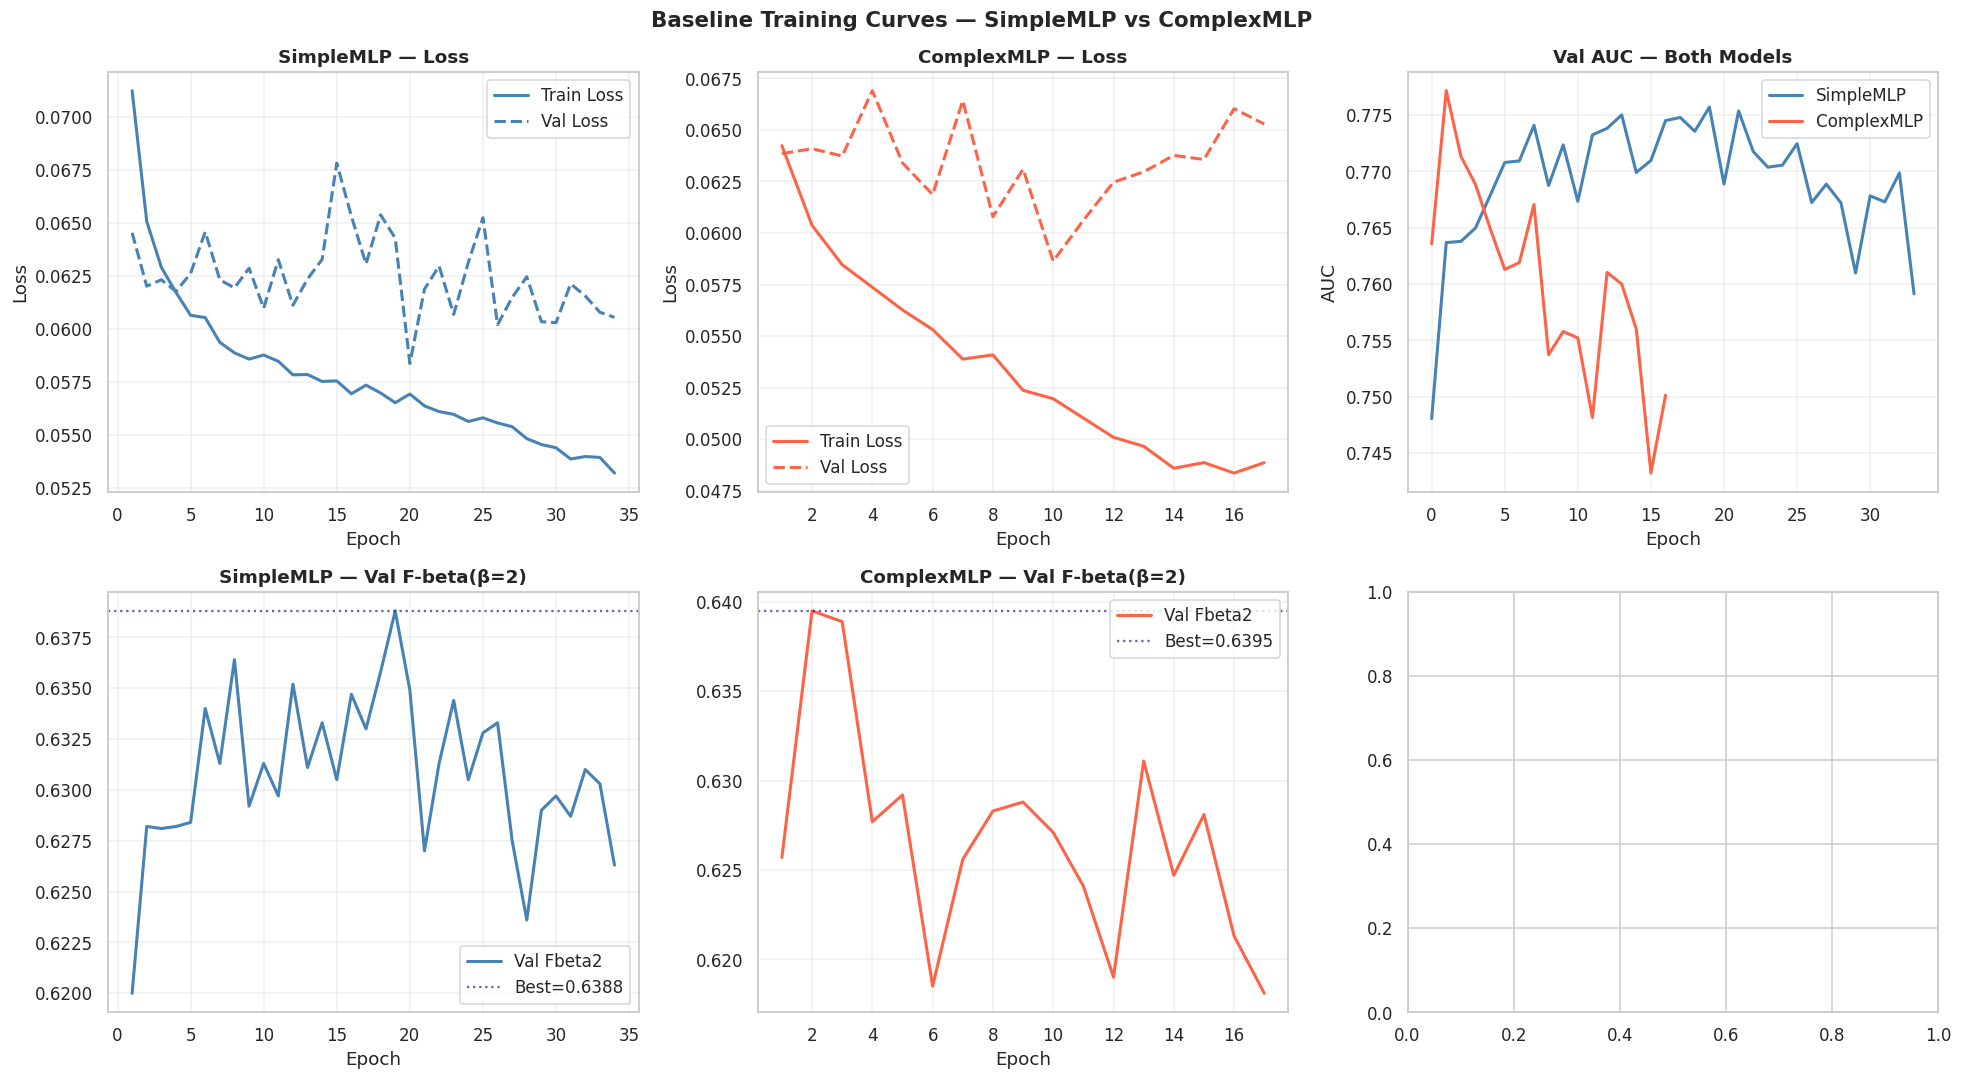

In [10]:
# ── Baseline training curves ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
model_colors = {"SimpleMLP": "steelblue", "ComplexMLP": "tomato"}

for col, (model_name, history) in enumerate(baseline_histories.items()):
    color = model_colors[model_name]
    epochs = range(1, len(history["train_loss"]) + 1)

    # Loss
    axes[0, col].plot(epochs, history["train_loss"], label="Train Loss", color=color, lw=2)
    axes[0, col].plot(epochs, history["val_loss"],   label="Val Loss",   color=color, lw=2, linestyle="--")
    axes[0, col].set_title(f"{model_name} — Loss", fontweight="bold")
    axes[0, col].set_xlabel("Epoch"); axes[0, col].set_ylabel("Loss")
    axes[0, col].legend(); axes[0, col].grid(True, alpha=0.3)

    # Val Fbeta2
    axes[1, col].plot(epochs, history["val_fbeta2"], color=color, lw=2, label="Val Fbeta2")
    axes[1, col].axhline(max(history["val_fbeta2"]), color="navy",
                          linestyle=":", alpha=0.6, label=f"Best={max(history['val_fbeta2']):.4f}")
    axes[1, col].set_title(f"{model_name} — Val F-beta(β=2)", fontweight="bold")
    axes[1, col].set_xlabel("Epoch"); axes[1, col].legend(); axes[1, col].grid(True, alpha=0.3)

# Overlay AUC
axes[0, 2].set_visible(False)
ax_auc = fig.add_subplot(2, 3, 3)
for model_name, history in baseline_histories.items():
    ax_auc.plot(history["val_auc"], label=model_name, color=model_colors[model_name], lw=2)
ax_auc.set_title("Val AUC — Both Models", fontweight="bold")
ax_auc.set_xlabel("Epoch"); ax_auc.set_ylabel("AUC")
ax_auc.legend(); ax_auc.grid(True, alpha=0.3)

plt.suptitle("Baseline Training Curves — SimpleMLP vs ComplexMLP",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("/tmp/baseline_training_curves.png", dpi=120, bbox_inches="tight")
plt.show()


## 7 — Hyperparameter Tuning — Optuna
> Separate study for each model — avoids parameter namespace conflicts.  
> Objective: **maximise F-beta(β=2)** on validation set at best threshold.


In [11]:
# ── Optuna objective — SimpleMLP ─────────────────────────────────────────────
def objective_simple(trial):
    # Architecture
    n_layers   = trial.suggest_int(  "n_layers",    2, 5)
    hidden_dim = trial.suggest_categorical("hidden_dim", [64, 128, 256, 512])
    dropout    = trial.suggest_float("dropout",     0.1, 0.6)

    # Build decreasing hidden dims: [hidden_dim, hidden_dim//2, ...]
    hidden_dims = tuple(max(32, hidden_dim // (2**i)) for i in range(n_layers))
    model = SimpleMLP(N_FEATURES, hidden_dims=hidden_dims, dropout_rate=dropout).to(DEVICE)

    # Training HPs
    lr           = trial.suggest_float("lr",           1e-4, 5e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    focal_alpha  = trial.suggest_float("focal_alpha",  0.5,  0.9)
    focal_gamma  = trial.suggest_float("focal_gamma",  1.0,  4.0)
    scheduler    = trial.suggest_categorical("scheduler", ["onecycle", "cosine"])

    _, _, best_fbeta2 = train_model(
        model, train_loader, val_loader,
        n_epochs       = 60,
        lr             = lr,
        weight_decay   = weight_decay,
        focal_alpha    = focal_alpha,
        focal_gamma    = focal_gamma,
        scheduler_type = scheduler,
        patience       = 10,
        verbose        = False,
    )
    return best_fbeta2


# ── Optuna objective — ComplexMLP ─────────────────────────────────────────────
def objective_complex(trial):
    # Architecture
    hidden_dim = trial.suggest_categorical("hidden_dim", [128, 256, 512])
    n_blocks   = trial.suggest_int(  "n_blocks",  2, 6)
    dropout    = trial.suggest_float("dropout",   0.1, 0.5)
    model      = ComplexMLP(N_FEATURES, hidden_dim=hidden_dim,
                             n_blocks=n_blocks, dropout_rate=dropout).to(DEVICE)

    # Training HPs
    lr           = trial.suggest_float("lr",           1e-4, 5e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    focal_alpha  = trial.suggest_float("focal_alpha",  0.5,  0.9)
    focal_gamma  = trial.suggest_float("focal_gamma",  1.0,  4.0)
    scheduler    = trial.suggest_categorical("scheduler", ["onecycle", "cosine"])

    _, _, best_fbeta2 = train_model(
        model, train_loader, val_loader,
        n_epochs       = 60,
        lr             = lr,
        weight_decay   = weight_decay,
        focal_alpha    = focal_alpha,
        focal_gamma    = focal_gamma,
        scheduler_type = scheduler,
        patience       = 10,
        verbose        = False,
    )
    return best_fbeta2


print("✅ Optuna objectives defined.")
print("   SimpleMLP  : tunes n_layers, hidden_dim, dropout, lr, wd, focal_alpha, focal_gamma, scheduler")
print("   ComplexMLP : tunes hidden_dim, n_blocks, dropout, lr, wd, focal_alpha, focal_gamma, scheduler")


✅ Optuna objectives defined.
   SimpleMLP  : tunes n_layers, hidden_dim, dropout, lr, wd, focal_alpha, focal_gamma, scheduler
   ComplexMLP : tunes hidden_dim, n_blocks, dropout, lr, wd, focal_alpha, focal_gamma, scheduler


In [12]:
# ── Run Optuna studies ────────────────────────────────────────────────────────
N_TRIALS = 30   # ← increase to 50+ for production

studies = {}

for model_name, objective in [("SimpleMLP", objective_simple),
                                ("ComplexMLP", objective_complex)]:
    print(f"\n🔍 Tuning {model_name} — {N_TRIALS} trials...")
    study = optuna.create_study(
        direction  = "maximize",
        study_name = f"{model_name}_study",
        sampler    = optuna.samplers.TPESampler(seed=RANDOM_STATE),
        pruner     = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5),
    )
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
    studies[model_name] = study

    print(f"  ✅ Best Fbeta2 : {study.best_value:.4f}")
    print(f"  ✅ Best params : {study.best_params}")

print("\n✅ All Optuna studies complete!")



🔍 Tuning SimpleMLP — 30 trials...


  0%|          | 0/30 [00:00<?, ?it/s]

  ✅ Best Fbeta2 : 0.6435
  ✅ Best params : {'n_layers': 2, 'hidden_dim': 256, 'dropout': 0.5969213925248544, 'lr': 0.003822471435580883, 'weight_decay': 0.0003485538204647836, 'focal_alpha': 0.828887494264863, 'focal_gamma': 2.6232761937807374, 'scheduler': 'onecycle'}

🔍 Tuning ComplexMLP — 30 trials...


  0%|          | 0/30 [00:00<?, ?it/s]

  ✅ Best Fbeta2 : 0.6460
  ✅ Best params : {'hidden_dim': 128, 'n_blocks': 4, 'dropout': 0.4937992127062441, 'lr': 0.0005435278637107489, 'weight_decay': 0.003202497410297695, 'focal_alpha': 0.6396415869317199, 'focal_gamma': 1.010869906011079, 'scheduler': 'cosine'}

✅ All Optuna studies complete!


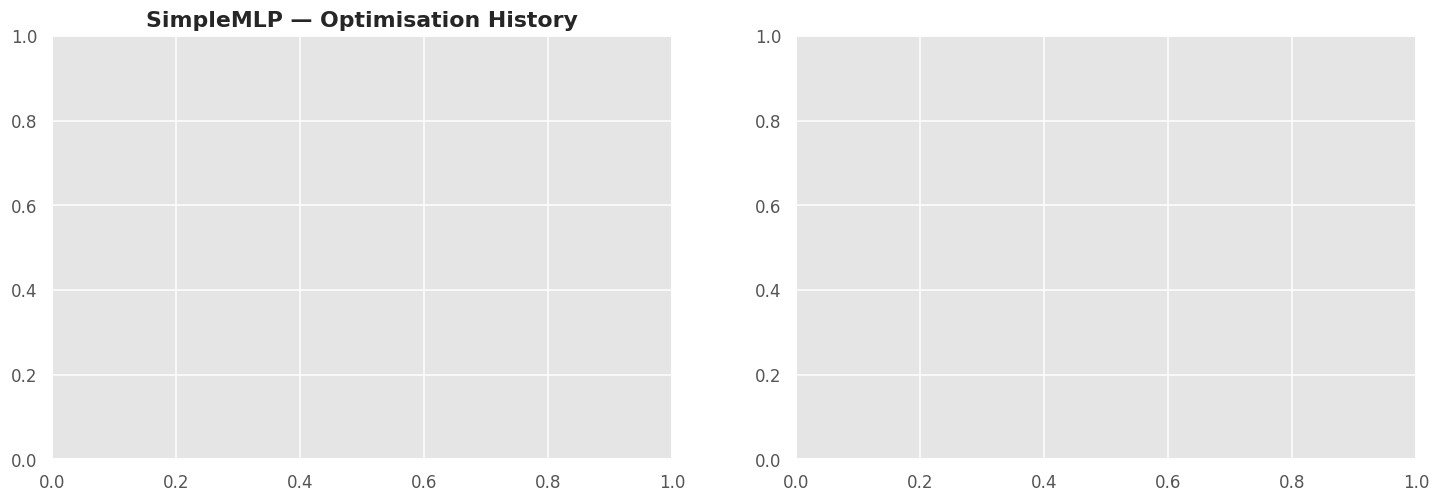

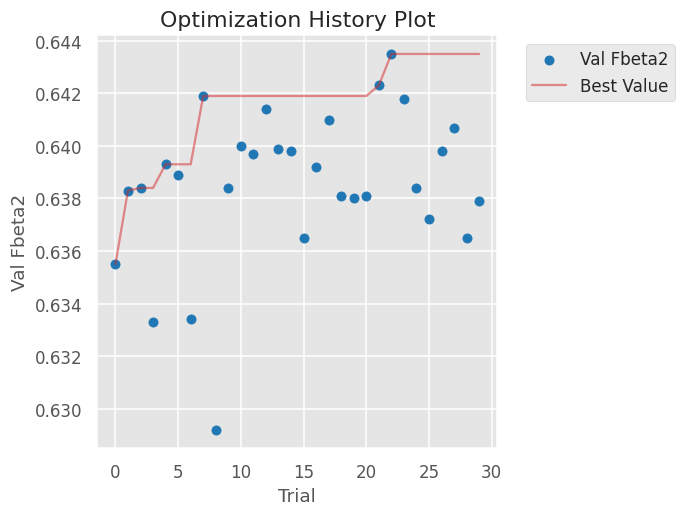

<Figure size 1760x550 with 0 Axes>

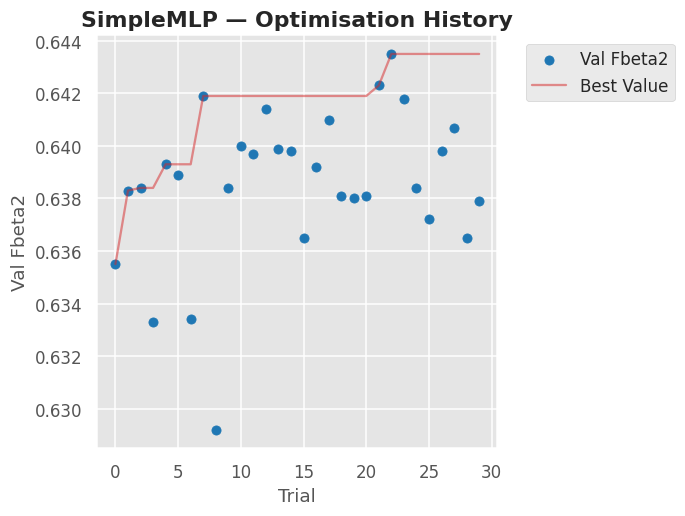

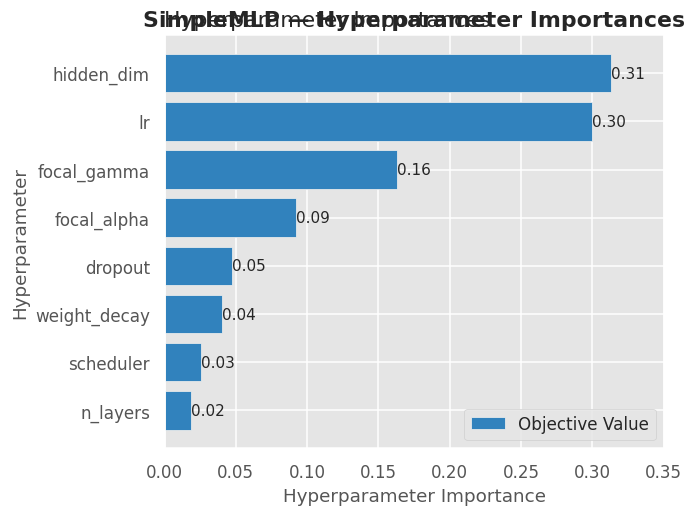

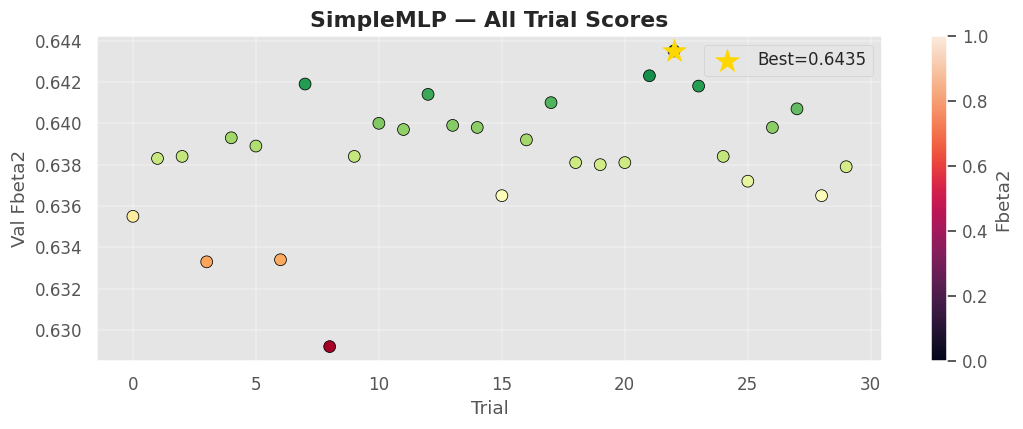


📊 SimpleMLP — Top 5 trials:


,number,val_fbeta2
22,22,0.6435
21,21,0.6423
7,7,0.6419
23,23,0.6418
12,12,0.6414


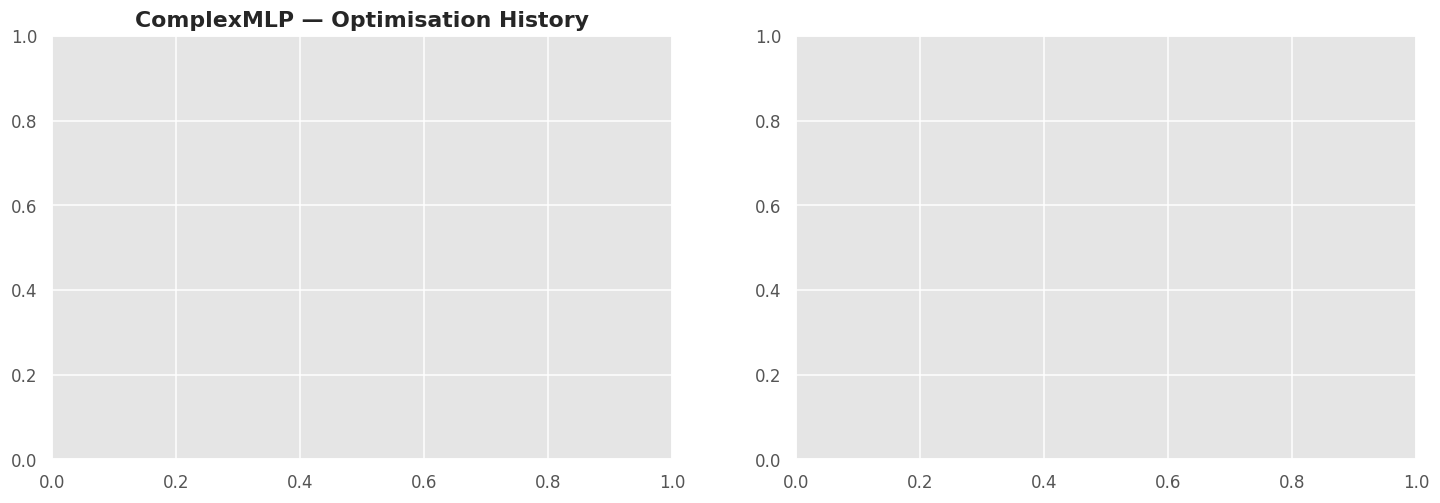

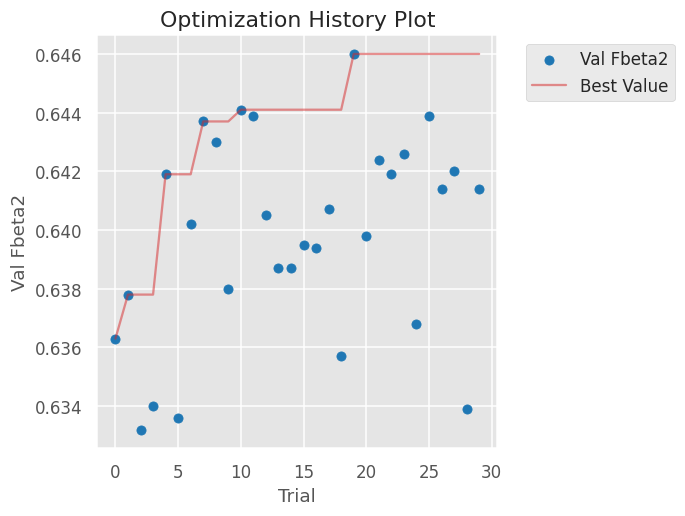

<Figure size 1760x550 with 0 Axes>

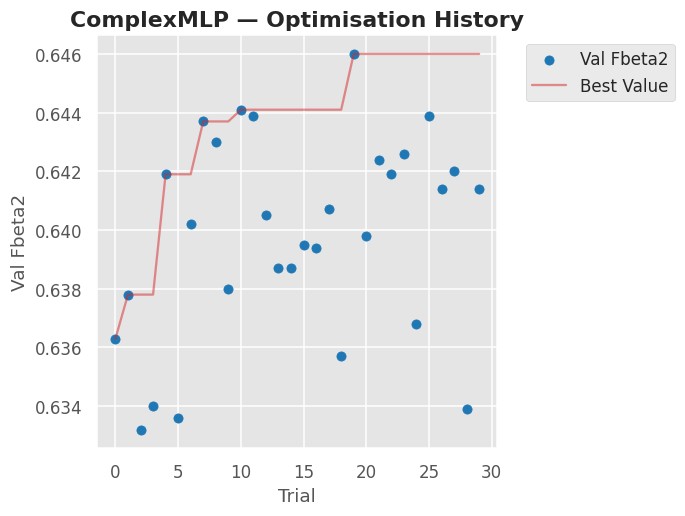

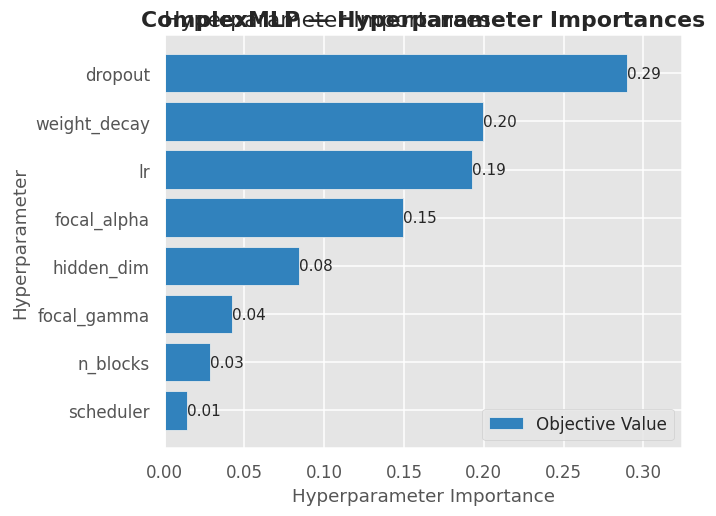

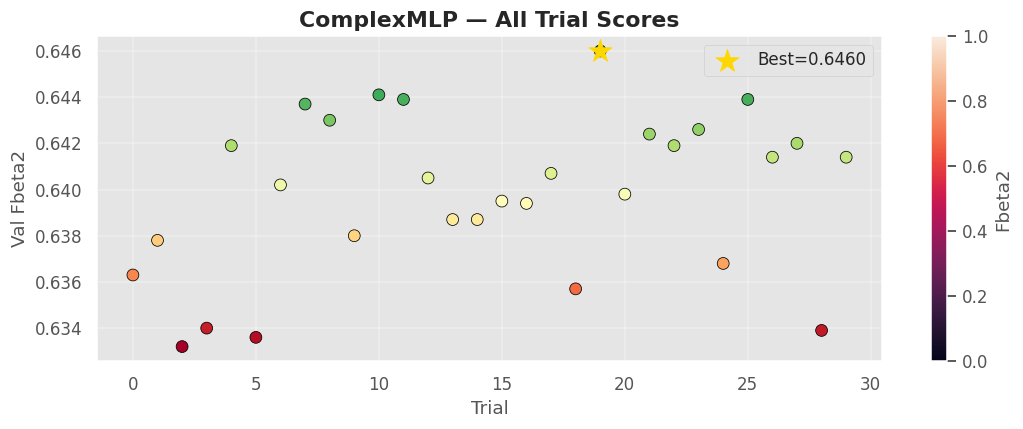


📊 ComplexMLP — Top 5 trials:


,number,val_fbeta2
19,19,0.6460
10,10,0.6441
25,25,0.6439
11,11,0.6439
7,7,0.6437


In [14]:
# ── Optuna visualisations ────────────────────────────────────────────────────
from optuna.visualization.matplotlib import (
    plot_optimization_history, plot_param_importances)

for model_name, study in studies.items():
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    plt.sca(axes[0])
    plot_optimization_history(study, target_name="Val Fbeta2")
    plt.gcf()
    axes[0].set_title(f"{model_name} — Optimisation History", fontweight="bold")

    plt.figure(figsize=(16, 5))
    plot_optimization_history(study, target_name="Val Fbeta2")
    plt.title(f"{model_name} — Optimisation History", fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"/tmp/optuna_history_{model_name}.png", dpi=110, bbox_inches="tight")
    plt.show()

    plot_param_importances(study)
    plt.title(f"{model_name} — Hyperparameter Importances", fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"/tmp/optuna_params_{model_name}.png", dpi=110, bbox_inches="tight")
    plt.show()

    # Trial score scatter
    trials_df = study.trials_dataframe()
    trials_df = trials_df[trials_df["state"] == "COMPLETE"]

    plt.figure(figsize=(10, 4))
    plt.scatter(trials_df["number"], trials_df["value"],
                c=trials_df["value"], cmap="RdYlGn", s=60,
                edgecolors="black", linewidths=0.5)
    best_row = trials_df.loc[trials_df["value"].idxmax()]
    plt.scatter(best_row["number"], best_row["value"],
                color="gold", s=250, marker="*", zorder=5,
                label=f"Best={best_row['value']:.4f}")
    plt.colorbar(label="Fbeta2")
    plt.xlabel("Trial"); plt.ylabel("Val Fbeta2")
    plt.title(f"{model_name} — All Trial Scores", fontweight="bold")
    plt.legend(); plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"/tmp/optuna_scatter_{model_name}.png", dpi=110, bbox_inches="tight")
    plt.show()

    print(f"\n📊 {model_name} — Top 5 trials:")
    top5 = (trials_df[["number","value"]]
            .sort_values("value", ascending=False)
            .head(5)
            .rename(columns={"value": "val_fbeta2"}))
    display(top5.style
        .background_gradient(cmap="RdYlGn", subset=["val_fbeta2"])
        .format({"val_fbeta2": "{:.4f}"}))


## 8 — Final Training with Best Optuna Config

In [15]:
# ── Rebuild and retrain both models with best params ─────────────────────────
tuned_results   = {}
tuned_histories = {}

for model_name, study in studies.items():
    best_p = study.best_params
    print(f"\n{'='*55}")
    print(f"  Final training: {model_name}")
    print(f"  Best params   : {best_p}")
    print(f"{'='*55}")

    # ── Build model from best params ──────────────────────────────────────────
    if model_name == "SimpleMLP":
        n_layers    = best_p["n_layers"]
        hidden_dim  = best_p["hidden_dim"]
        dropout     = best_p["dropout"]
        hidden_dims = tuple(max(32, hidden_dim // (2**i)) for i in range(n_layers))
        model = SimpleMLP(N_FEATURES, hidden_dims=hidden_dims, dropout_rate=dropout)
    else:
        model = ComplexMLP(
            N_FEATURES,
            hidden_dim   = best_p["hidden_dim"],
            n_blocks     = best_p["n_blocks"],
            dropout_rate = best_p["dropout"],
        )

    model      = model.to(DEVICE)
    n_params   = sum(p.numel() for p in model.parameters())

    # ── Train on train+val combined ───────────────────────────────────────────
    X_trainval = np.vstack([X_train, X_val])
    y_trainval = np.concatenate([y_train, y_val])
    tv_ds      = CreditCardDataset(X_trainval, y_trainval)

    class_counts   = np.bincount(y_trainval.astype(int))
    sample_weights = (1.0 / class_counts)[y_trainval.astype(int)]
    sampler_tv     = WeightedRandomSampler(
        torch.FloatTensor(sample_weights), len(tv_ds), replacement=True)
    tv_loader      = DataLoader(tv_ds, batch_size=512, sampler=sampler_tv,
                                 num_workers=2, pin_memory=True)

    with mlflow.start_run(run_name=f"tuned_{model_name}") as run:
        mlflow.set_tag("model_type", "DL_PyTorch")
        mlflow.set_tag("architecture", model_name)
        mlflow.set_tag("stage", "tuned")
        mlflow.log_params({**best_p, "n_params": n_params, "model": model_name})

        model, history, best_val_score = train_model(
            model, tv_loader, val_loader,
            n_epochs       = 150,
            lr             = best_p["lr"],
            weight_decay   = best_p["weight_decay"],
            focal_alpha    = best_p["focal_alpha"],
            focal_gamma    = best_p["focal_gamma"],
            scheduler_type = best_p["scheduler"],
            patience       = 20,
            verbose        = True,
            log_mlflow     = True,
        )

        # Threshold from val set (not test — no leakage)
        val_probs,  val_labels  = get_proba(model, val_loader)
        test_probs, test_labels = get_proba(model, test_loader)
        best_t, _               = find_best_threshold(val_labels, val_probs, beta=2)
        test_metrics            = compute_metrics(test_labels, test_probs,
                                                   threshold=best_t, prefix="test_")

        mlflow.log_metrics({**test_metrics, "best_threshold": best_t})
        mlflow.pytorch.log_model(model, "model",
                                  registered_model_name=f"credit_default_{model_name}")

        run_id = run.info.run_id

    tuned_results[model_name] = {
        "model"       : model,
        "threshold"   : best_t,
        "metrics"     : test_metrics,
        "y_prob_test" : test_probs,
        "y_prob_val"  : val_probs,
        "n_params"    : n_params,
        "best_params" : best_p,
        "run_id"      : run_id,
    }
    tuned_histories[model_name] = history

    print(f"\n  Threshold : {best_t:.3f}")
    print(f"  Accuracy  : {test_metrics['test_accuracy']:.4f}")
    print(f"  Precision : {test_metrics['test_precision']:.4f}")
    print(f"  Recall    : {test_metrics['test_recall']:.4f}")
    print(f"  F1        : {test_metrics['test_f1']:.4f}")
    print(f"  Fbeta2    : {test_metrics['test_fbeta2']:.4f}")
    print(f"  ROC-AUC   : {test_metrics['test_roc_auc']:.4f}")
    print(f"  Run ID    : {run_id}")



  Final training: SimpleMLP
  Best params   : {'n_layers': 2, 'hidden_dim': 256, 'dropout': 0.5969213925248544, 'lr': 0.003822471435580883, 'weight_decay': 0.0003485538204647836, 'focal_alpha': 0.828887494264863, 'focal_gamma': 2.6232761937807374, 'scheduler': 'onecycle'}
  Ep   10 | train=0.0331 | val_loss=0.0352 | val_Fbeta2=0.6268 | val_AUC=0.7703
  Ep   20 | train=0.0325 | val_loss=0.0329 | val_Fbeta2=0.6371 | val_AUC=0.7784
  Ep   30 | train=0.0324 | val_loss=0.0352 | val_Fbeta2=0.6378 | val_AUC=0.7795
  Ep   40 | train=0.0327 | val_loss=0.0320 | val_Fbeta2=0.6413 | val_AUC=0.7867
  ⏹ Early stop @ epoch 48. Best Fbeta2=0.6487


2026/06/14 15:05:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/14 15:05:20 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/14 15:05:20 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/06/14 15:05:29 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cpu) contains a local version label (+cpu

🏃 View run tuned_SimpleMLP at: https://almighty-bacterium-undrafted.ngrok-free.dev/#/experiments/2/runs/06f57beab9df409ab333db97c1e1d8df
🧪 View experiment at: https://almighty-bacterium-undrafted.ngrok-free.dev/#/experiments/2

  Threshold : 0.550
  Accuracy  : 0.5313
  Precision : 0.3016
  Recall    : 0.8499
  F1        : 0.4452
  Fbeta2    : 0.6233
  ROC-AUC   : 0.7666
  Run ID    : 06f57beab9df409ab333db97c1e1d8df

  Final training: ComplexMLP
  Best params   : {'hidden_dim': 128, 'n_blocks': 4, 'dropout': 0.4937992127062441, 'lr': 0.0005435278637107489, 'weight_decay': 0.003202497410297695, 'focal_alpha': 0.6396415869317199, 'focal_gamma': 1.010869906011079, 'scheduler': 'cosine'}
  Ep   10 | train=0.1268 | val_loss=0.1358 | val_Fbeta2=0.6451 | val_AUC=0.7917
  Ep   20 | train=0.1174 | val_loss=0.1356 | val_Fbeta2=0.6603 | val_AUC=0.8036
  Ep   30 | train=0.1106 | val_loss=0.1286 | val_Fbeta2=0.6677 | val_AUC=0.8153
  Ep   40 | train=0.1052 | val_loss=0.1294 | val_Fbeta2=0.6781 | v

2026/06/14 15:20:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/14 15:20:19 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/14 15:20:19 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/06/14 15:20:25 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cpu) contains a local version label (+cpu

🏃 View run tuned_ComplexMLP at: https://almighty-bacterium-undrafted.ngrok-free.dev/#/experiments/2/runs/bbdeb80c45b341d0b983e62b2ddd0260
🧪 View experiment at: https://almighty-bacterium-undrafted.ngrok-free.dev/#/experiments/2

  Threshold : 0.610
  Accuracy  : 0.6599
  Precision : 0.3553
  Recall    : 0.6591
  F1        : 0.4617
  Fbeta2    : 0.5629
  ROC-AUC   : 0.7148
  Run ID    : bbdeb80c45b341d0b983e62b2ddd0260


## 9 — Threshold Analysis — Winner Model

In [16]:
# ── Find winner model (best Fbeta2) ──────────────────────────────────────────
tuned_df = pd.DataFrame([
    {
        "Model"     : name,
        "Params"    : f"{res['n_params']:,}",
        "Threshold" : res["threshold"],
        "Accuracy"  : res["metrics"]["test_accuracy"],
        "Precision" : res["metrics"]["test_precision"],
        "Recall"    : res["metrics"]["test_recall"],
        "F1"        : res["metrics"]["test_f1"],
        "Fbeta2"    : res["metrics"]["test_fbeta2"],
        "ROC-AUC"   : res["metrics"]["test_roc_auc"],
    }
    for name, res in tuned_results.items()
]).set_index("Model")

display(tuned_df.style
    .background_gradient(cmap="RdYlGn", subset=["Recall","F1","Fbeta2","ROC-AUC","Accuracy"])
    .format({"Threshold": "{:.3f}", "Accuracy": "{:.4f}", "Precision": "{:.4f}",
             "Recall": "{:.4f}", "F1": "{:.4f}", "Fbeta2": "{:.4f}", "ROC-AUC": "{:.4f}"})
    .set_caption("🏆 Tuned Models — Test Set Performance"))

WINNER_NAME    = tuned_df["Fbeta2"].idxmax()
winner_result  = tuned_results[WINNER_NAME]
winner_probs   = winner_result["y_prob_test"]
winner_val_p   = winner_result["y_prob_val"]

print(f"\n🏆 WINNER MODEL : {WINNER_NAME}")
print(f"   Fbeta2       : {tuned_df.loc[WINNER_NAME, 'Fbeta2']:.4f}")
print(f"   Recall       : {tuned_df.loc[WINNER_NAME, 'Recall']:.4f}")
print(f"   F1           : {tuned_df.loc[WINNER_NAME, 'F1']:.4f}")


,Params,Threshold,Accuracy,Precision,Recall,F1,Fbeta2,ROC-AUC
Model,,,,,,,,
SimpleMLP,"43,777",0.550,0.5313,0.3016,0.8499,0.4452,0.6233,0.7666
ComplexMLP,"288,259",0.610,0.6599,0.3553,0.6591,0.4617,0.5629,0.7148



🏆 WINNER MODEL : SimpleMLP
   Fbeta2       : 0.6233
   Recall       : 0.8499
   F1           : 0.4452


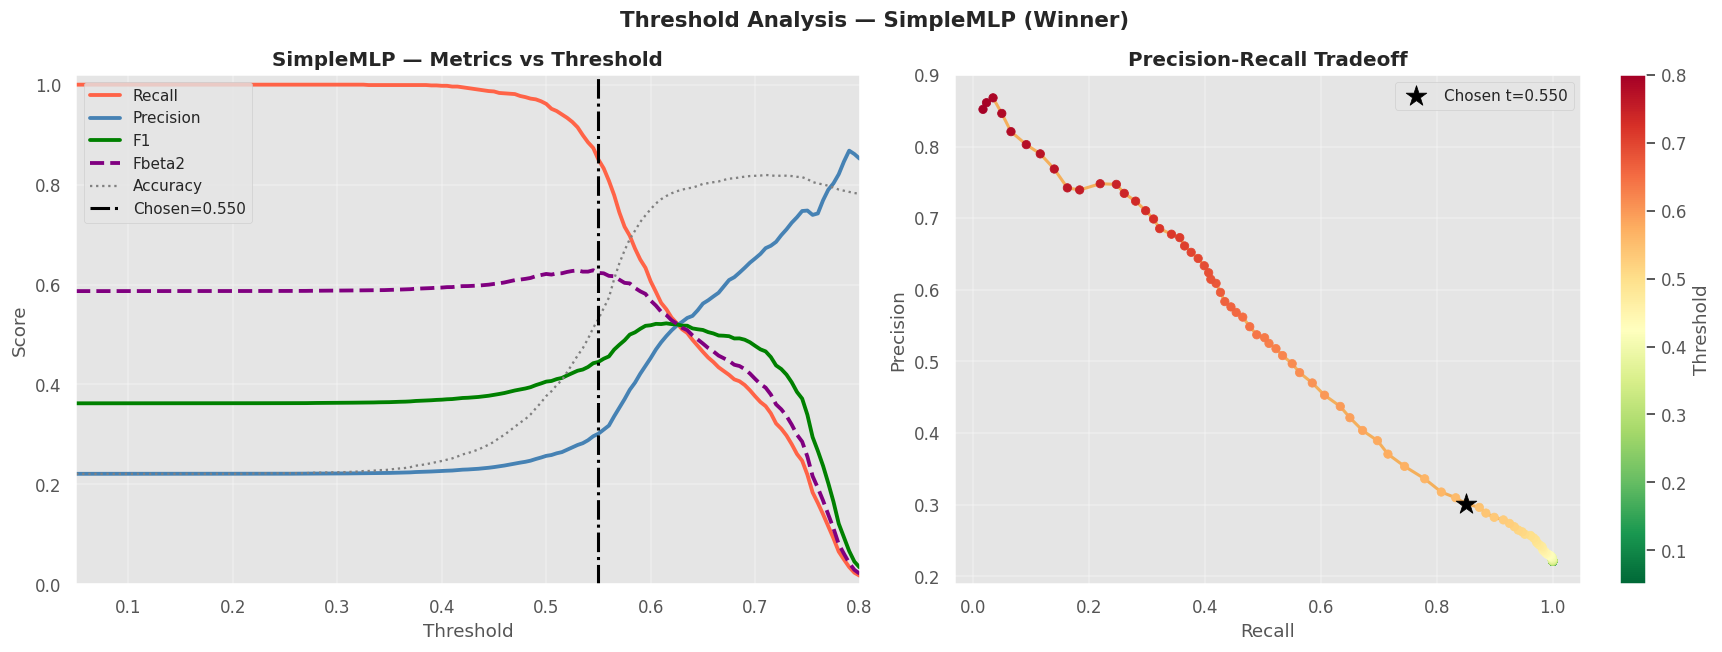

THRESHOLD RECOMMENDATIONS — SimpleMLP

🟢 Best F1      → t=0.615  Rec=0.5505  Pre=0.4969  F1=0.5224
🟣 Best Fbeta2  → t=0.545  Rec=0.8733  Pre=0.2964  F1=0.4426
🟡 Recall≥0.80  → t=0.560  Rec=0.8077  Pre=0.3178  F1=0.4561
🟠 Recall≥0.85  → t=0.545  Rec=0.8733  Pre=0.2964  F1=0.4426
🔴 Recall≥0.90  → t=0.530  Rec=0.9148  Pre=0.2789  F1=0.4275



,recall,precision,f1,fbeta2,accuracy
threshold,,,,,
0.200000,1.0000,0.2213,0.3623,0.5869,0.2213
0.250000,1.0000,0.2215,0.3626,0.5872,0.2223
0.300000,1.0000,0.2219,0.3632,0.5878,0.2243
0.350000,0.9992,0.2230,0.3647,0.5892,0.2296
0.400000,0.9977,0.2268,0.3696,0.5940,0.2470
0.500000,0.9615,0.2572,0.4058,0.6212,0.3769


In [17]:
# ── Full threshold sweep on winner model ──────────────────────────────────────
thresholds = np.linspace(0.05, 0.80, 151)
thresh_rows = []

for t in thresholds:
    y_pred = (winner_probs >= t).astype(int)
    thresh_rows.append({
        "threshold" : round(t, 3),
        "recall"    : recall_score(y_test, y_pred,    zero_division=0),
        "precision" : precision_score(y_test, y_pred, zero_division=0),
        "f1"        : f1_score(y_test, y_pred,        zero_division=0),
        "fbeta2"    : fbeta_score(y_test, y_pred, beta=2, zero_division=0),
        "accuracy"  : accuracy_score(y_test, y_pred),
    })

thresh_df = pd.DataFrame(thresh_rows)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left — all metrics vs threshold
axes[0].plot(thresh_df["threshold"], thresh_df["recall"],    label="Recall",    color="tomato",    lw=2.5)
axes[0].plot(thresh_df["threshold"], thresh_df["precision"], label="Precision", color="steelblue", lw=2.5)
axes[0].plot(thresh_df["threshold"], thresh_df["f1"],        label="F1",        color="green",     lw=2.5)
axes[0].plot(thresh_df["threshold"], thresh_df["fbeta2"],    label="Fbeta2",    color="purple",    lw=2.5, linestyle="--")
axes[0].plot(thresh_df["threshold"], thresh_df["accuracy"],  label="Accuracy",  color="gray",      lw=1.5, linestyle=":")
axes[0].axvline(winner_result["threshold"], color="black", linestyle="-.", lw=2,
                label=f"Chosen={winner_result['threshold']:.3f}")
axes[0].set_xlabel("Threshold", fontsize=12)
axes[0].set_ylabel("Score",     fontsize=12)
axes[0].set_title(f"{WINNER_NAME} — Metrics vs Threshold", fontweight="bold", fontsize=13)
axes[0].legend(fontsize=10); axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0.05, 0.80); axes[0].set_ylim(0, 1.02)

# Right — precision-recall tradeoff
sc = axes[1].scatter(thresh_df["recall"], thresh_df["precision"],
                      c=thresh_df["threshold"], cmap="RdYlGn_r", s=30, zorder=3)
axes[1].plot(thresh_df["recall"], thresh_df["precision"],
             color="darkorange", lw=2, alpha=0.6)
plt.colorbar(sc, ax=axes[1], label="Threshold")

# Mark chosen threshold
chosen_row = thresh_df[thresh_df["threshold"] == winner_result["threshold"]].iloc[0]
axes[1].scatter(chosen_row["recall"], chosen_row["precision"],
                color="black", s=200, marker="*", zorder=5,
                label=f"Chosen t={winner_result['threshold']:.3f}")
axes[1].set_xlabel("Recall",    fontsize=12)
axes[1].set_ylabel("Precision", fontsize=12)
axes[1].set_title("Precision-Recall Tradeoff", fontweight="bold", fontsize=13)
axes[1].legend(fontsize=10); axes[1].grid(True, alpha=0.3)

plt.suptitle(f"Threshold Analysis — {WINNER_NAME} (Winner)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("/tmp/threshold_analysis_winner.png", dpi=120, bbox_inches="tight")
plt.show()

# ── Recommendations ───────────────────────────────────────────────────────────
print("=" * 65)
print(f"THRESHOLD RECOMMENDATIONS — {WINNER_NAME}")
print("=" * 65)

best_f1_row = thresh_df.loc[thresh_df["f1"].idxmax()]
print(f"\n🟢 Best F1      → t={best_f1_row['threshold']:.3f}"
      f"  Rec={best_f1_row['recall']:.4f}  Pre={best_f1_row['precision']:.4f}  F1={best_f1_row['f1']:.4f}")

best_fb_row = thresh_df.loc[thresh_df["fbeta2"].idxmax()]
print(f"🟣 Best Fbeta2  → t={best_fb_row['threshold']:.3f}"
      f"  Rec={best_fb_row['recall']:.4f}  Pre={best_fb_row['precision']:.4f}  F1={best_fb_row['f1']:.4f}")

for target, emoji, label in [(0.80,"🟡","0.80"),(0.85,"🟠","0.85"),(0.90,"🔴","0.90")]:
    sub = thresh_df[thresh_df["recall"] >= target].sort_values("f1", ascending=False)
    if not sub.empty:
        r = sub.iloc[0]
        print(f"{emoji} Recall≥{label}  → t={r['threshold']:.3f}"
              f"  Rec={r['recall']:.4f}  Pre={r['precision']:.4f}  F1={r['f1']:.4f}")

print()
key_df = thresh_df[thresh_df["threshold"].isin([0.50,0.40,0.35,0.30,0.25,0.20])].set_index("threshold")
display(key_df.style
    .background_gradient(cmap="RdYlGn", subset=["recall","f1","fbeta2","accuracy"])
    .background_gradient(cmap="RdYlGn_r", subset=["precision"])
    .format("{:.4f}")
    .set_caption(f"📊 Key Thresholds — {WINNER_NAME}"))


## 10 — Full Evaluation — All Metrics & Visualisations

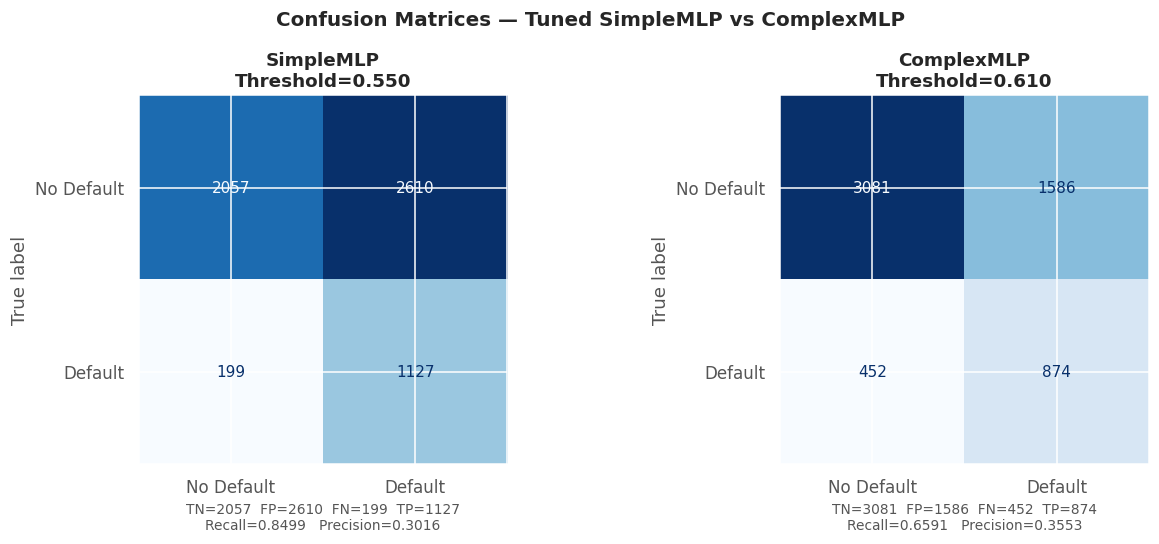

In [18]:
# ── 10.1  Confusion matrices — both tuned models ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, res) in zip(axes, tuned_results.items()):
    y_pred = (res["y_prob_test"] >= res["threshold"]).astype(int)
    cm     = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    ConfusionMatrixDisplay(cm, display_labels=["No Default","Default"]).plot(
        ax=ax, colorbar=False, cmap="Blues")

    ax.set_title(f"{name}\nThreshold={res['threshold']:.3f}", fontweight="bold", fontsize=12)
    ax.set_xlabel(
        f"TN={tn}  FP={fp}  FN={fn}  TP={tp}\n"
        f"Recall={tp/(tp+fn):.4f}   Precision={tp/(tp+fp):.4f}",
        fontsize=9
    )

plt.suptitle("Confusion Matrices — Tuned SimpleMLP vs ComplexMLP",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("/tmp/confusion_matrices_tuned.png", dpi=120, bbox_inches="tight")
plt.show()


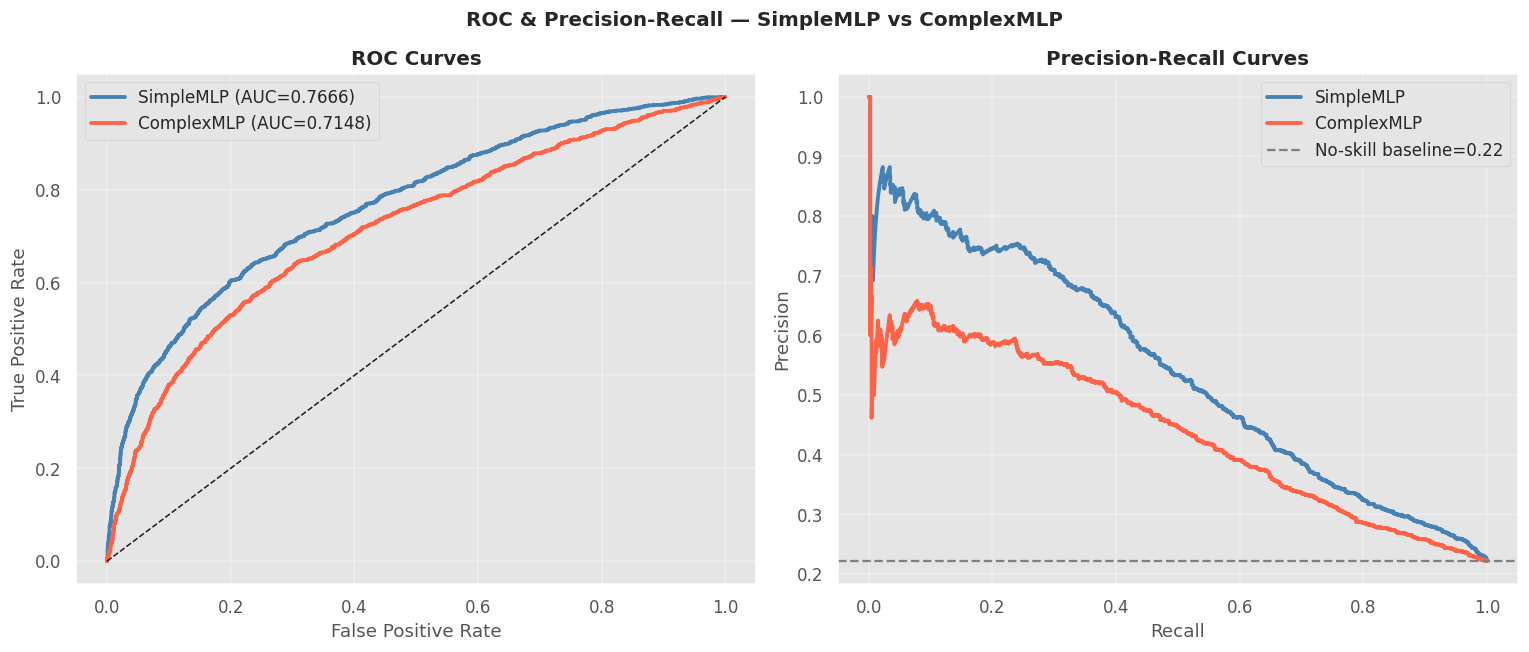

In [19]:
# ── 10.2  ROC curves ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors    = {"SimpleMLP": "steelblue", "ComplexMLP": "tomato"}

# ROC
for name, res in tuned_results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_prob_test"])
    auc          = res["metrics"]["test_roc_auc"]
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc:.4f})",
                 color=colors[name], lw=2.5)

axes[0].plot([0,1],[0,1],"k--", lw=1)
axes[0].set_xlabel("False Positive Rate", fontsize=12)
axes[0].set_ylabel("True Positive Rate",  fontsize=12)
axes[0].set_title("ROC Curves", fontweight="bold", fontsize=13)
axes[0].legend(fontsize=11); axes[0].grid(True, alpha=0.3)

# Precision-Recall
baseline = y_test.mean()
for name, res in tuned_results.items():
    pre, rec, _ = precision_recall_curve(y_test, res["y_prob_test"])
    axes[1].plot(rec, pre, label=name, color=colors[name], lw=2.5)

axes[1].axhline(baseline, color="gray", linestyle="--", lw=1.5,
                label=f"No-skill baseline={baseline:.2f}")
axes[1].set_xlabel("Recall",    fontsize=12)
axes[1].set_ylabel("Precision", fontsize=12)
axes[1].set_title("Precision-Recall Curves", fontweight="bold", fontsize=13)
axes[1].legend(fontsize=11); axes[1].grid(True, alpha=0.3)

plt.suptitle("ROC & Precision-Recall — SimpleMLP vs ComplexMLP",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("/tmp/roc_pr_curves.png", dpi=120, bbox_inches="tight")
plt.show()


In [20]:
# ── 10.3  Classification reports ─────────────────────────────────────────────
for name, res in tuned_results.items():
    y_pred = (res["y_prob_test"] >= res["threshold"]).astype(int)
    print(f"{'='*55}")
    print(f"  {name}  (threshold={res['threshold']:.3f})")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred,
                                 target_names=["No Default","Default"],
                                 digits=4))


  SimpleMLP  (threshold=0.550)
              precision    recall  f1-score   support

  No Default     0.9118    0.4408    0.5943      4667
     Default     0.3016    0.8499    0.4452      1326

    accuracy                         0.5313      5993
   macro avg     0.6067    0.6453    0.5197      5993
weighted avg     0.7768    0.5313    0.5613      5993

  ComplexMLP  (threshold=0.610)
              precision    recall  f1-score   support

  No Default     0.8721    0.6602    0.7515      4667
     Default     0.3553    0.6591    0.4617      1326

    accuracy                         0.6599      5993
   macro avg     0.6137    0.6596    0.6066      5993
weighted avg     0.7577    0.6599    0.6874      5993



In [21]:
# ── 10.4  Error analysis table ───────────────────────────────────────────────
error_rows = []
for name, res in tuned_results.items():
    y_pred = (res["y_prob_test"] >= res["threshold"]).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    error_rows.append({
        "Model"                  : name,
        "TP (caught defaulters)" : tp,
        "FN (missed defaulters)" : fn,
        "FP (false alarms)"      : fp,
        "TN (correct)"          : tn,
        "Recall (TPR)"           : round(tp / (tp + fn), 4),
        "Miss Rate (FNR)"        : round(fn / (tp + fn), 4),
        "False Alarm Rate"       : round(fp / (fp + tn), 4),
        "Precision"              : round(tp / (tp + fp), 4),
    })

error_df = pd.DataFrame(error_rows).set_index("Model")
display(error_df.style
    .background_gradient(cmap="RdYlGn",   subset=["TP (caught defaulters)","Recall (TPR)","Precision"])
    .background_gradient(cmap="RdYlGn_r", subset=["FN (missed defaulters)","Miss Rate (FNR)","False Alarm Rate"])
    .format({"Recall (TPR)": "{:.4f}", "Miss Rate (FNR)": "{:.4f}",
             "False Alarm Rate": "{:.4f}", "Precision": "{:.4f}"})
    .set_caption("📊 Error Analysis — What Each Model Gets Wrong"))

print(f"\nTotal defaulters in test set     : {int(y_test.sum())}")
print(f"Total non-defaulters in test set : {int((y_test==0).sum())}")


,TP (caught defaulters),FN (missed defaulters),FP (false alarms),TN (correct),Recall (TPR),Miss Rate (FNR),False Alarm Rate,Precision
Model,,,,,,,,
SimpleMLP,1127,199,2610,2057,0.8499,0.1501,0.5592,0.3016
ComplexMLP,874,452,1586,3081,0.6591,0.3409,0.3398,0.3553



Total defaulters in test set     : 1326
Total non-defaulters in test set : 4667


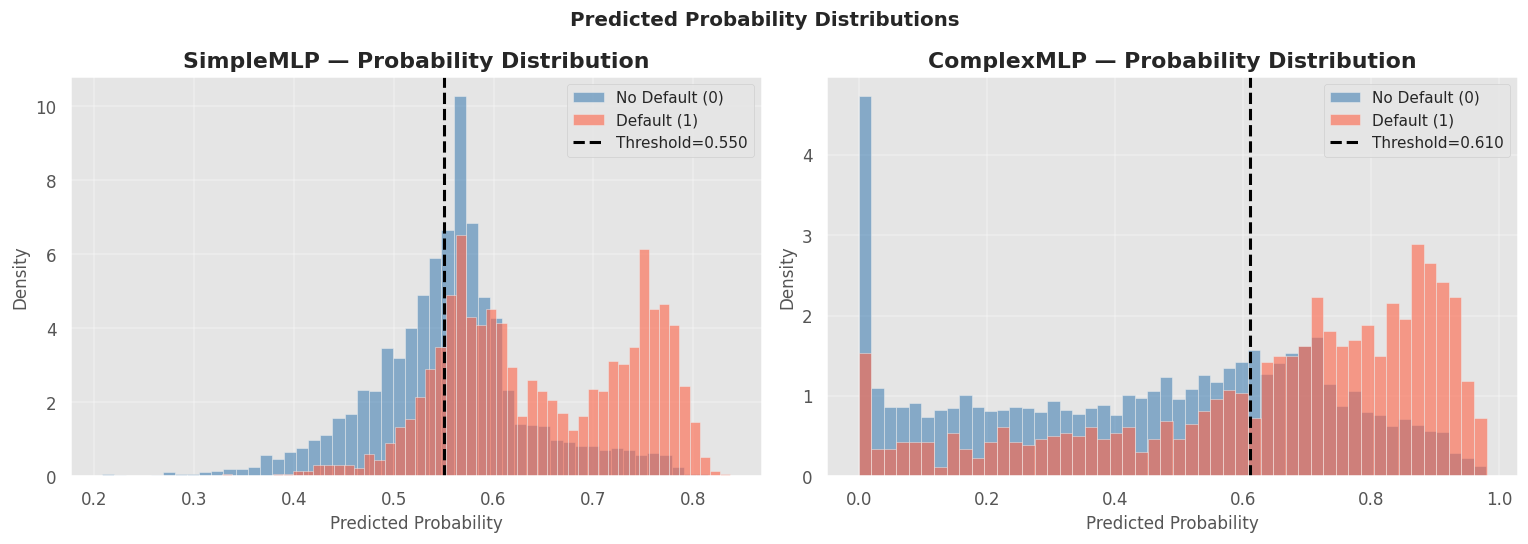

In [22]:
# ── 10.5  Probability distribution ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, res) in zip(axes, tuned_results.items()):
    probs = res["y_prob_test"]
    ax.hist(probs[y_test == 0], bins=50, alpha=0.6, color="steelblue",
            label="No Default (0)", density=True)
    ax.hist(probs[y_test == 1], bins=50, alpha=0.6, color="tomato",
            label="Default (1)", density=True)
    ax.axvline(res["threshold"], color="black", linestyle="--", lw=2,
               label=f"Threshold={res['threshold']:.3f}")
    ax.set_xlabel("Predicted Probability", fontsize=11)
    ax.set_ylabel("Density", fontsize=11)
    ax.set_title(f"{name} — Probability Distribution", fontweight="bold")
    ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

plt.suptitle("Predicted Probability Distributions", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("/tmp/prob_distributions.png", dpi=120, bbox_inches="tight")
plt.show()


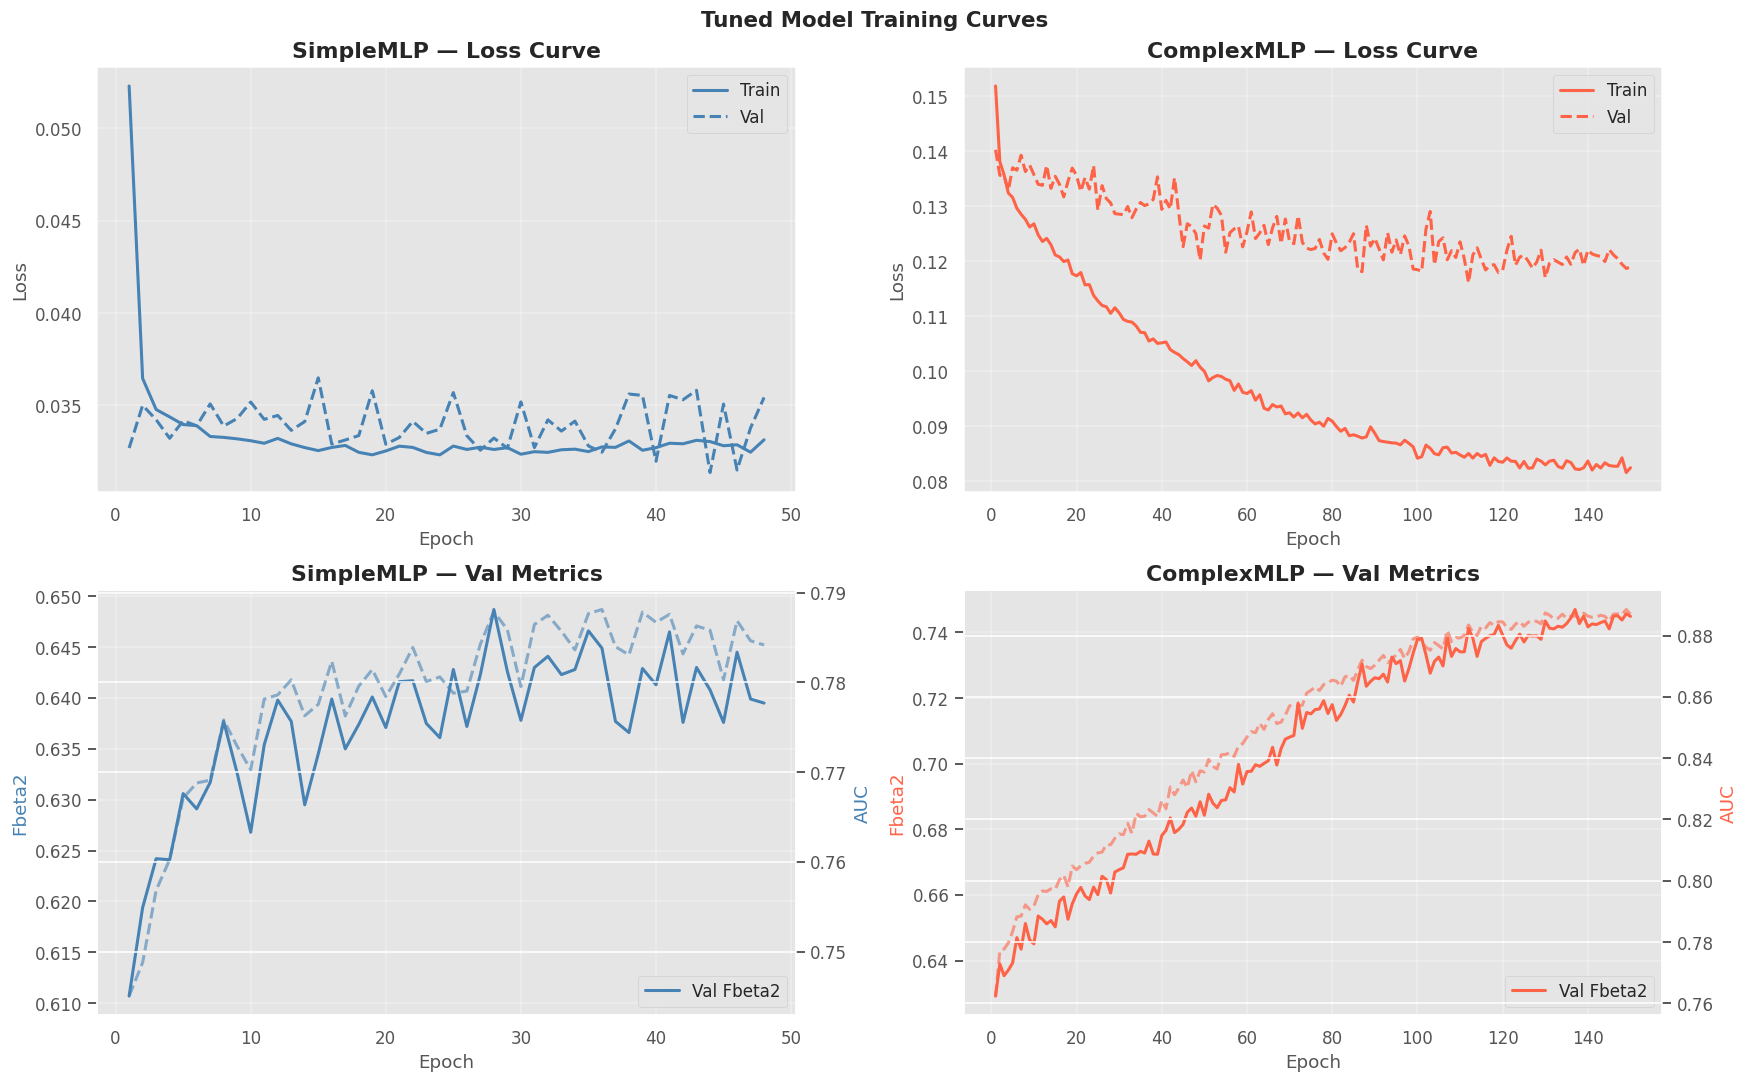

In [23]:
# ── 10.6  Training curves — tuned models ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for col, (name, history) in enumerate(tuned_histories.items()):
    color  = colors[name]
    epochs = range(1, len(history["train_loss"]) + 1)

    axes[0, col].plot(epochs, history["train_loss"], label="Train", color=color, lw=2)
    axes[0, col].plot(epochs, history["val_loss"],   label="Val",   color=color, lw=2, linestyle="--")
    axes[0, col].set_title(f"{name} — Loss Curve", fontweight="bold")
    axes[0, col].set_xlabel("Epoch"); axes[0, col].set_ylabel("Loss")
    axes[0, col].legend(); axes[0, col].grid(True, alpha=0.3)

    ax2 = axes[1, col].twinx()
    axes[1, col].plot(epochs, history["val_fbeta2"], label="Val Fbeta2",
                      color=color, lw=2)
    ax2.plot(epochs, history["val_auc"], label="Val AUC",
             color=color, lw=2, linestyle="--", alpha=0.6)
    axes[1, col].set_title(f"{name} — Val Metrics", fontweight="bold")
    axes[1, col].set_xlabel("Epoch")
    axes[1, col].set_ylabel("Fbeta2", color=color)
    ax2.set_ylabel("AUC", color=color)
    axes[1, col].legend(loc="lower right"); axes[1, col].grid(True, alpha=0.3)

plt.suptitle("Tuned Model Training Curves", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("/tmp/tuned_training_curves.png", dpi=120, bbox_inches="tight")
plt.show()


## 11 — Model Comparison Dashboard

In [24]:
# ── Full comparison — Baseline vs Tuned ──────────────────────────────────────
all_rows = []
for name, res in baseline_results.items():
    m = res["metrics"]
    all_rows.append({"Model": f"{name} (Baseline)", "Stage": "Baseline",
                     "Accuracy": m["test_accuracy"], "Precision": m["test_precision"],
                     "Recall": m["test_recall"], "F1": m["test_f1"],
                     "Fbeta2": m["test_fbeta2"], "ROC-AUC": m["test_roc_auc"],
                     "Threshold": res["threshold"]})

for name, res in tuned_results.items():
    m = res["metrics"]
    all_rows.append({"Model": f"{name} (Tuned)", "Stage": "Tuned",
                     "Accuracy": m["test_accuracy"], "Precision": m["test_precision"],
                     "Recall": m["test_recall"], "F1": m["test_f1"],
                     "Fbeta2": m["test_fbeta2"], "ROC-AUC": m["test_roc_auc"],
                     "Threshold": res["threshold"]})

all_df = pd.DataFrame(all_rows).set_index("Model").drop(columns=["Stage"])
all_df = all_df.sort_values("Fbeta2", ascending=False)

display(all_df.style
    .background_gradient(cmap="RdYlGn", subset=["Recall","F1","Fbeta2","ROC-AUC","Accuracy"])
    .format({"Threshold": "{:.3f}", "Accuracy": "{:.4f}", "Precision": "{:.4f}",
             "Recall": "{:.4f}", "F1": "{:.4f}", "Fbeta2": "{:.4f}", "ROC-AUC": "{:.4f}"})
    .set_caption("🏆 Full Leaderboard — Baseline vs Tuned"))


,Accuracy,Precision,Recall,F1,Fbeta2,ROC-AUC,Threshold
Model,,,,,,,
SimpleMLP (Tuned),0.5313,0.3016,0.8499,0.4452,0.6233,0.7666,0.550
ComplexMLP (Baseline),0.5488,0.3083,0.8356,0.4504,0.6226,0.7594,0.535
SimpleMLP (Baseline),0.5279,0.2992,0.8446,0.4419,0.6190,0.7563,0.540
ComplexMLP (Tuned),0.6599,0.3553,0.6591,0.4617,0.5629,0.7148,0.610


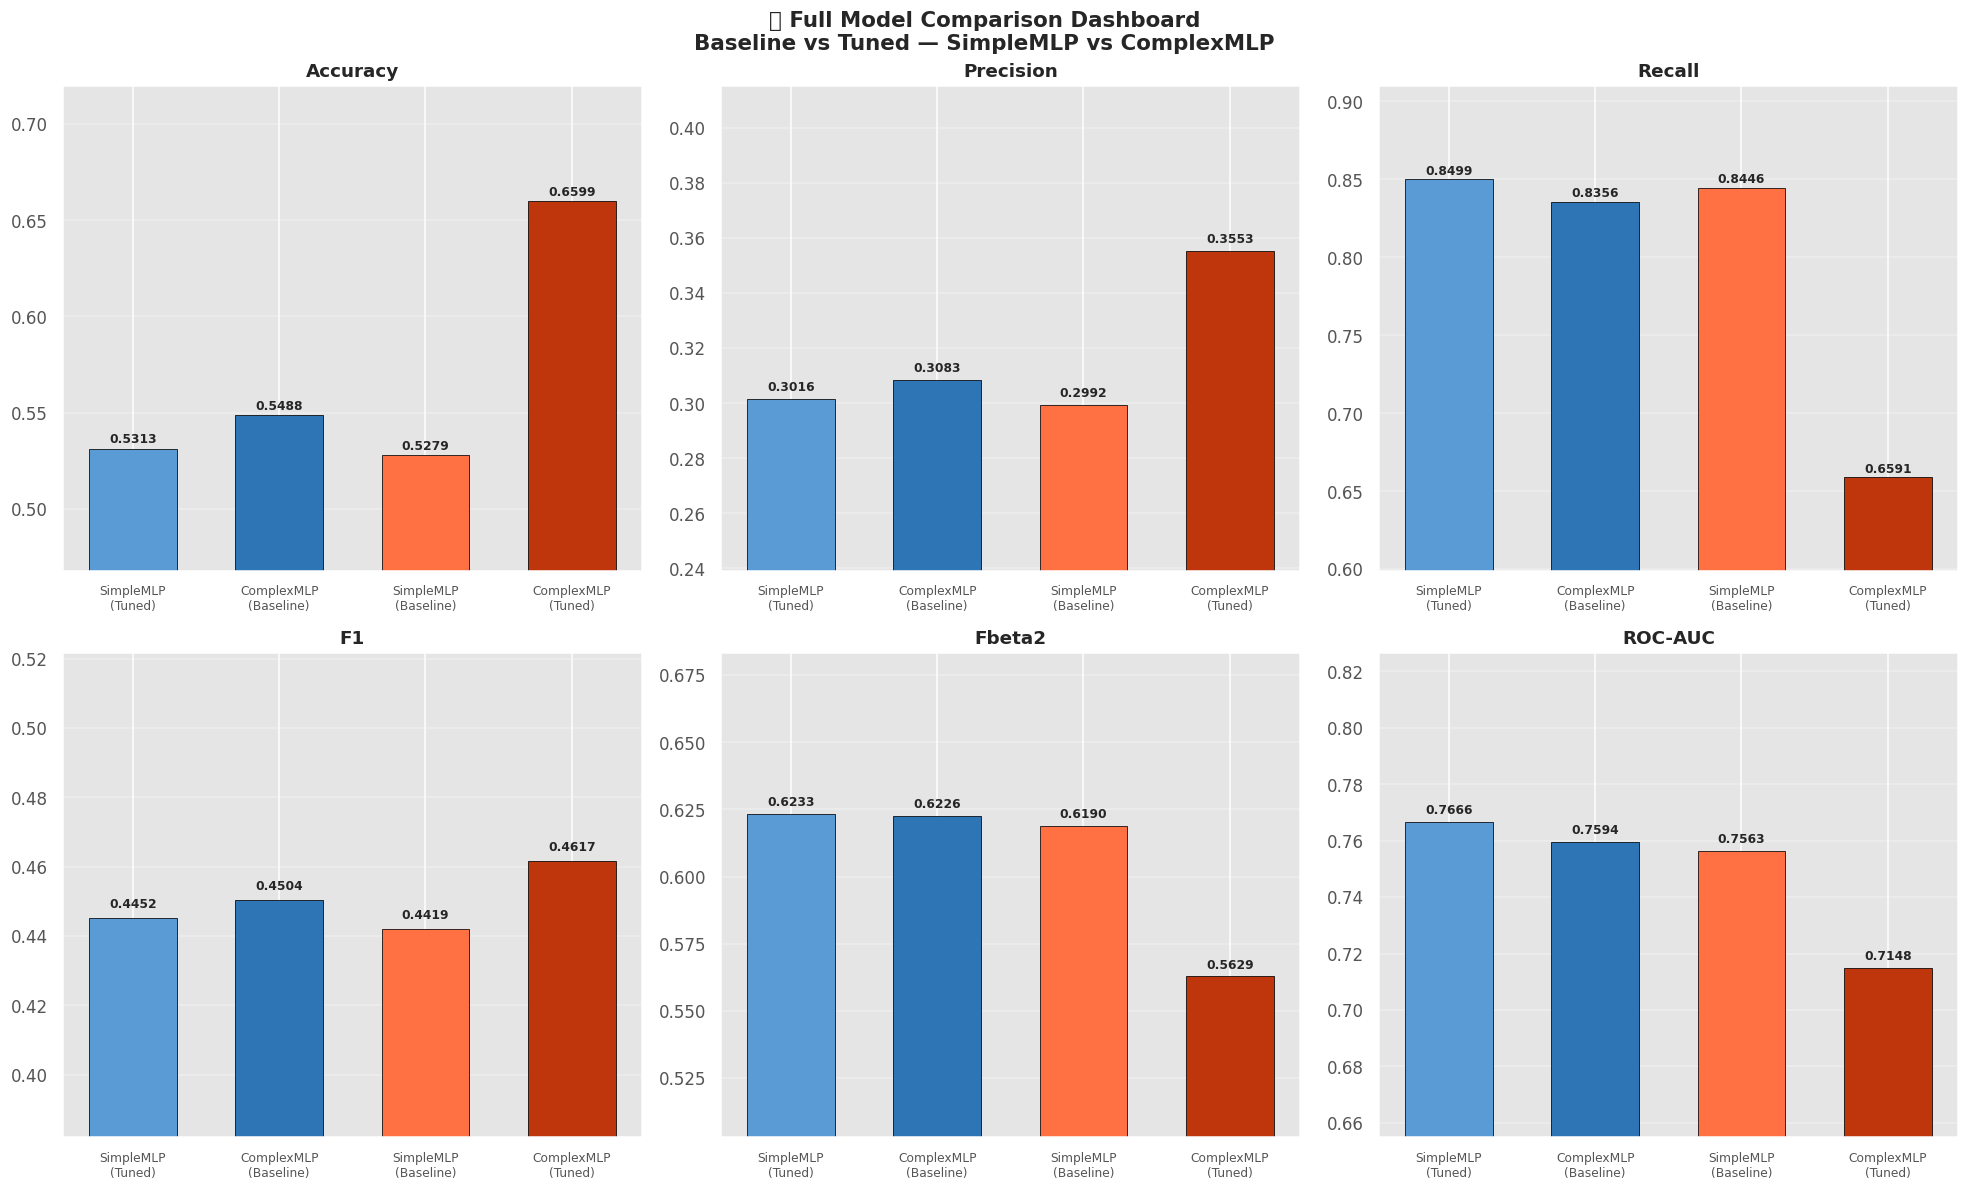


🏆 WINNER : SimpleMLP (Tuned)
   Fbeta2  : 0.6233
   Recall  : 0.8499
   F1      : 0.4452


In [25]:
# ── Bar chart dashboard ───────────────────────────────────────────────────────
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1", "Fbeta2", "ROC-AUC"]
n_metrics       = len(metrics_to_plot)

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
bar_colors = ["#5B9BD5","#2E75B6","#FF7043","#BF360C"]   # light/dark per model

for ax, metric in zip(axes.flatten(), metrics_to_plot):
    vals  = all_df[metric].values
    names = [n.replace(" (","\n(") for n in all_df.index.tolist()]
    bars  = ax.bar(names, vals, color=bar_colors[:len(vals)], edgecolor="black", width=0.6)
    ax.set_ylim(max(0, vals.min() - 0.06), min(1.03, vals.max() + 0.06))
    ax.set_title(metric, fontweight="bold", fontsize=12)
    ax.set_xticklabels(names, fontsize=8)
    ax.grid(True, alpha=0.3, axis="y")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.003,
                f"{val:.4f}", ha="center", fontsize=8, fontweight="bold")

plt.suptitle("🏆 Full Model Comparison Dashboard\nBaseline vs Tuned — SimpleMLP vs ComplexMLP",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("/tmp/full_comparison_dashboard.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"\n🏆 WINNER : {all_df['Fbeta2'].idxmax()}")
print(f"   Fbeta2  : {all_df['Fbeta2'].max():.4f}")
print(f"   Recall  : {all_df.loc[all_df['Fbeta2'].idxmax(), 'Recall']:.4f}")
print(f"   F1      : {all_df.loc[all_df['Fbeta2'].idxmax(), 'F1']:.4f}")


## 12 — Save All Models + MLflow Registry

In [26]:
# ── Save all models locally ───────────────────────────────────────────────────
saved_paths = {}

# Baseline models
for name, res in baseline_results.items():
    path = MODEL_PATH + f"{name}_baseline.pt"
    torch.save({
        "model_state_dict" : res["model"].state_dict(),
        "model_name"       : name,
        "stage"            : "baseline",
        "threshold"        : res["threshold"],
        "feature_cols"     : feature_cols,
        "n_features"       : N_FEATURES,
        "metrics"          : res["metrics"],
        "n_params"         : res["n_params"],
    }, path)
    saved_paths[f"{name}_baseline"] = path
    print(f"✅ Saved {name} baseline → {path}")

# Tuned models
for name, res in tuned_results.items():
    path = MODEL_PATH + f"{name}_tuned.pt"
    torch.save({
        "model_state_dict" : res["model"].state_dict(),
        "model_name"       : name,
        "stage"            : "tuned",
        "threshold"        : res["threshold"],
        "feature_cols"     : feature_cols,
        "n_features"       : N_FEATURES,
        "metrics"          : res["metrics"],
        "best_params"      : res["best_params"],
        "n_params"         : res["n_params"],
        "run_id"           : res["run_id"],
    }, path)
    saved_paths[f"{name}_tuned"] = path
    print(f"✅ Saved {name} tuned   → {path}")

print(f"\n✅ All models saved to: {MODEL_PATH}")


✅ Saved SimpleMLP baseline → /content/drive/MyDrive/ml_projects/credit_card_default_v1/models/dl/SimpleMLP_baseline.pt
✅ Saved ComplexMLP baseline → /content/drive/MyDrive/ml_projects/credit_card_default_v1/models/dl/ComplexMLP_baseline.pt
✅ Saved SimpleMLP tuned   → /content/drive/MyDrive/ml_projects/credit_card_default_v1/models/dl/SimpleMLP_tuned.pt
✅ Saved ComplexMLP tuned   → /content/drive/MyDrive/ml_projects/credit_card_default_v1/models/dl/ComplexMLP_tuned.pt

✅ All models saved to: /content/drive/MyDrive/ml_projects/credit_card_default_v1/models/dl/


In [27]:
# ── Save best model separately ────────────────────────────────────────────────
BEST_MODEL_NAME   = WINNER_NAME
best_result       = tuned_results[BEST_MODEL_NAME]

best_path = MODEL_PATH + f"BEST_MODEL_{BEST_MODEL_NAME}.pt"
torch.save({
    "model_state_dict" : best_result["model"].state_dict(),
    "model_name"       : BEST_MODEL_NAME,
    "threshold"        : best_result["threshold"],
    "feature_cols"     : feature_cols,
    "n_features"       : N_FEATURES,
    "metrics"          : best_result["metrics"],
    "best_params"      : best_result["best_params"],
}, best_path)

print(f"✅ Best model saved → {best_path}")

# Summary JSON
summary = {
    "best_model"    : BEST_MODEL_NAME,
    "stage"         : "tuned",
    "threshold"     : float(best_result["threshold"]),
    "fbeta2"        : float(best_result["metrics"]["test_fbeta2"]),
    "f1"            : float(best_result["metrics"]["test_f1"]),
    "recall"        : float(best_result["metrics"]["test_recall"]),
    "precision"     : float(best_result["metrics"]["test_precision"]),
    "accuracy"      : float(best_result["metrics"]["test_accuracy"]),
    "roc_auc"       : float(best_result["metrics"]["test_roc_auc"]),
    "mlflow_run_id" : best_result["run_id"],
    "model_path"    : best_path,
}
with open(MODEL_PATH + "best_dl_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("\n✅ Best model summary:")
print(json.dumps(summary, indent=2))


✅ Best model saved → /content/drive/MyDrive/ml_projects/credit_card_default_v1/models/dl/BEST_MODEL_SimpleMLP.pt

✅ Best model summary:
{
  "best_model": "SimpleMLP",
  "stage": "tuned",
  "threshold": 0.55,
  "fbeta2": 0.6233,
  "f1": 0.4452,
  "recall": 0.8499,
  "precision": 0.3016,
  "accuracy": 0.5313,
  "roc_auc": 0.7666,
  "mlflow_run_id": "06f57beab9df409ab333db97c1e1d8df",
  "model_path": "/content/drive/MyDrive/ml_projects/credit_card_default_v1/models/dl/BEST_MODEL_SimpleMLP.pt"
}


In [28]:
# ── Register best model to MLflow Production ─────────────────────────────────
from mlflow.tracking import MlflowClient
client = MlflowClient()

best_run_id = best_result["run_id"]
model_uri   = f"runs:/{best_run_id}/model"

registered = mlflow.register_model(
    model_uri = model_uri,
    name      = "credit_default_DL_best"
)

client.transition_model_version_stage(
    name                      = "credit_default_DL_best",
    version                   = registered.version,
    stage                     = "Production",
    archive_existing_versions = True,
)

print(f"✅ MLflow Registry:")
print(f"   Name    : credit_default_DL_best")
print(f"   Model   : {BEST_MODEL_NAME}")
print(f"   Version : {registered.version}")
print(f"   Stage   : Production")
print(f"   Run ID  : {best_run_id}")


Successfully registered model 'credit_default_DL_best'.
2026/06/14 15:20:40 WARNING mlflow.tracking._model_registry.fluent: Run with id 06f57beab9df409ab333db97c1e1d8df has no artifacts at artifact path 'model', registering model based on models:/m-1d5260ba292747f6a3aab2a9bf868d73 instead
2026/06/14 15:20:40 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: credit_default_DL_best, version 1
Created version '1' of model 'credit_default_DL_best'.


✅ MLflow Registry:
   Name    : credit_default_DL_best
   Model   : SimpleMLP
   Version : 1
   Stage   : Production
   Run ID  : 06f57beab9df409ab333db97c1e1d8df


In [33]:
# ── How to load and use any saved model ──────────────────────────────────────
def load_dl_model(checkpoint_path, model_class, device=DEVICE):
    """Load any saved DL model from checkpoint."""
    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)

    name = ckpt["model_name"]

    if name == "SimpleMLP":
        # Read exact layer shapes from saved weights — don't guess
        state_dict = ckpt["model_state_dict"]

        # Extract all linear layer weight shapes in order
        linear_weights = [
            v for k, v in state_dict.items()
            if "weight" in k and len(v.shape) == 2  # 2D = Linear layer
        ]

        # hidden_dims = all intermediate layer output dims (skip last output layer)
        hidden_dims = tuple(w.shape[0] for w in linear_weights[:-1])

        print(f"Reconstructed hidden_dims: {hidden_dims}")

        model = SimpleMLP(ckpt["n_features"], hidden_dims=hidden_dims).to(device)
    else:
        bp    = ckpt.get("best_params", {})
        model = ComplexMLP(
            ckpt["n_features"],
            hidden_dim   = bp.get("hidden_dim", 256),
            n_blocks     = bp.get("n_blocks", 4),
            dropout_rate = bp.get("dropout", 0.3),
        ).to(device)

    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    return model, ckpt["threshold"], ckpt["feature_cols"]


def predict_dl(model, X_new, threshold, device=DEVICE):
    """Production inference."""
    model.eval()
    X_t = torch.from_numpy(X_new.astype(np.float32)).to(device)
    with torch.no_grad():
        logits = model(X_t).squeeze(1)
        probs  = torch.sigmoid(logits).cpu().numpy()
    preds = (probs >= threshold).astype(int)
    return preds, probs


# ── Example usage ─────────────────────────────────────────────────────────────
print("Example: Load best model and predict on test set")
print()

model_loaded, threshold_loaded, features_loaded = load_dl_model(
    best_path,
    SimpleMLP if BEST_MODEL_NAME == "SimpleMLP" else ComplexMLP
)

y_pred_loaded, y_prob_loaded = predict_dl(model_loaded, X_test, threshold_loaded)

print(f"Model     : {BEST_MODEL_NAME}")
print(f"Threshold : {threshold_loaded:.3f}")
print(f"Recall    : {recall_score(y_test, y_pred_loaded):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_loaded):.4f}")
print(f"F1        : {f1_score(y_test, y_pred_loaded):.4f}")
print(f"Fbeta2    : {fbeta_score(y_test, y_pred_loaded, beta=2):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_prob_loaded):.4f}")


Example: Load best model and predict on test set

Reconstructed hidden_dims: (256, 128)
Model     : SimpleMLP
Threshold : 0.550
Recall    : 0.8499
Precision : 0.3016
F1        : 0.4452
Fbeta2    : 0.6233
ROC-AUC   : 0.7666


## 📌 Notebook Summary

| Component | SimpleMLP | ComplexMLP |
|-----------|-----------|------------|
| Layers | 3 hidden (256→128→64) | 6 residual blocks |
| Special | BatchNorm + ReLU | Feature Attention + Skip connections + GELU |
| Parameters | ~50K | ~500K+ |
| Speed | ⚡ Fast | 🐢 Slower |

| Step | Details |
|------|---------|
| Loss | FocalLoss (α, γ tuned by Optuna) |
| Sampler | WeightedRandomSampler |
| Scheduler | OneCycleLR / CosineAnnealingLR (tuned) |
| Tuning | Optuna TPE, separate study per model |
| Objective | F-beta(β=2) — recall-weighted |
| Threshold | Auto-selected on val set (best Fbeta2) |
| Saved | Baseline + Tuned + Best model checkpoints (.pt) |
| MLflow | `credit_default_DL_best` → Production |

### 🔁 Backend fetch
```python
import mlflow, torch
mlflow.set_tracking_uri("https://YOUR-NGROK-URL.ngrok-free.app")
model = mlflow.pytorch.load_model("models:/credit_default_DL_best/Production")
```
